### Training For Baseline Without Optimizer

In [14]:
# Import Libraries
import numpy as np
import pandas as pd
import os
import sys
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample, class_weight
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Import model, modelIO
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  # project root
from src.model.lstm_cupy_optimized import LSTMModelGPUOptimized, GPU_AVAILABLE
from src.model.lstm_bidirectional import BiLSTMModelGPUOptimized
from src.model.lstm_nested import NestedLSTMModelGPUOptimized
from src.model.lstm_peephole import PeepholeLSTMModelGPUOptimized
from src.model.lstm_cifg import CIFGLSTMModelGPUOptimized
from src.model.lstm_glu import GLULSTMModelGPUOptimized
from src.model.lstm_layernorm import LayerNormLSTMModelGPUOptimized
from src.model.lstm_residual import ResidualLSTMModelGPUOptimized
from src.utils.model_io import save_model, load_and_build_model

# Model registry untuk loop experiments
MODEL_REGISTRY = {
    # 'Optimized': LSTMModelGPUOptimized,
    # 'BiDirectional': BiLSTMModelGPUOptimized,
    # 'Nested': NestedLSTMModelGPUOptimized,
    # 'Peephole': PeepholeLSTMModelGPUOptimized,
    'CIFG': CIFGLSTMModelGPUOptimized,
    'GLU': GLULSTMModelGPUOptimized,
    'LayerNorm': LayerNormLSTMModelGPUOptimized,
    'Residual': ResidualLSTMModelGPUOptimized
}

# Export path
CHECKPOINT_PATH = os.path.join(os.getcwd(), '..', 'src/model/checkpoints/lstm_optimized.pkl')
print(CHECKPOINT_PATH)
print(f"📦 Available models: {list(MODEL_REGISTRY.keys())}")

c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints/lstm_optimized.pkl
📦 Available models: ['CIFG', 'GLU', 'LayerNorm', 'Residual']


In [15]:
# === 1. Load Data ===
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_DATA = os.path.join(DATA_DIR, 'raw_dataset.csv')
df = pd.read_csv(RAW_DATA)

# Check GPU
try:
    import cupy as cp
    GPU_AVAILABLE = True
    print("✅ CuPy detected - Using GPU acceleration")
    use_gpu = True
except ImportError:
    import numpy as cp
    GPU_AVAILABLE = False
    print("⚠️ CuPy not found - Falling back to NumPy (CPU)")
    use_gpu = False

✅ CuPy detected - Using GPU acceleration


In [16]:
# === 2. Preprocess Data ===
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Type'].str.contains('restoration', case=False, na=False)]
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['incident'] = ((df['Priority'] >= 2) & (df['Impact'] >= 2)).astype(int)

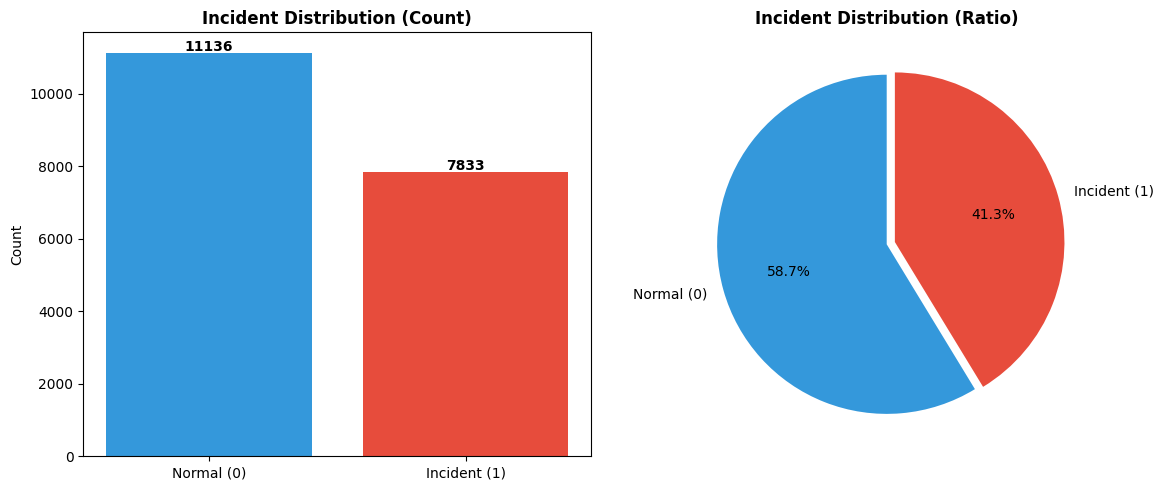


📊 Summary:
   Normal (0): 11,136 (58.7%)
   Incident (1): 7,833 (41.3%)
   Ratio: 1 : 1.4


In [17]:
# === 2.1 Check incident feature ratio ===
# Count values
counts = df['incident'].value_counts()
labels = ['Normal (0)', 'Incident (1)']
# Create figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Bar chart
axes[0].bar(labels, [counts.get(0, 0), counts.get(1, 0)], color=['#3498db', '#e74c3c'])
axes[0].set_title('Incident Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
# Pie chart
axes[1].pie([counts.get(0, 0), counts.get(1, 0)], labels=labels, autopct='%1.1f%%', 
            colors=['#3498db', '#e74c3c'], explode=(0, 0.05), startangle=90)
axes[1].set_title('Incident Distribution (Ratio)', fontweight='bold')
plt.tight_layout()
plt.show()
# Print summary
print(f"\n📊 Summary:")
print(f"   Normal (0): {counts.get(0, 0):,} ({counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"   Incident (1): {counts.get(1, 0):,} ({counts.get(1, 0)/len(df)*100:.1f}%)")
print(f"   Ratio: 1 : {counts.get(0, 0)/max(counts.get(1, 0), 1):.1f}")

In [18]:
# === 3. Base Functions/Procedures ===
# === 3.1 Windowing Function ===
def create_windowed_dataset(df, feature_cols, target_col, window_size):
    X, y, timestamps = [], [], []
    for i in range(len(df) - window_size):
        window = df[feature_cols].iloc[i:i+window_size].astype(float).values
        label = df[target_col].iloc[i+window_size]
        timestamp = df['Timestamp'].iloc[i+window_size]
        X.append(window)
        y.append(label)
        timestamps.append(timestamp)
    return np.array(X), np.array(y), np.array(timestamps)
        

In [19]:
# === 4. Training ===
def train_eval(X, y, label, model_type='Optimized', cw=1, hidden_size=128, patience=3, epochs=500, batch_size=128, lr=0.001, print_every=1, lambda_l2=0.0001):
    """
    Training and evaluation function with support for different LSTM model types.
    
    Args:
        X: Input features (samples, seq_len, features)
        y: Target labels
        label: Label string for identifying this experiment
        model_type: Type of LSTM model to use. Options:
                   'Optimized' (default), 'BiDirectional', 'Nested', 'Peephole'
        cw: Class weight for positive class
        hidden_size: Number of hidden units
        patience: Early stopping patience
        epochs: Maximum training epochs
        batch_size: Batch size for training
        lr: Learning rate
        print_every: Print metrics every N epochs
        lambda_l2: L2 regularization strength
    
    Returns:
        Dictionary containing metrics and predictions
    """
    # Split: 60% train, 20% val, 20% test
    X_temp, X_te, y_temp, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_tr, X_val, y_tr, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

    # Export training, val, test sets
    export_dir = '../data/splits'
    os.makedirs(export_dir, exist_ok=True)
    
    np.save(f'{export_dir}/X_train.npy', X_tr)
    np.save(f'{export_dir}/X_val.npy', X_val)
    np.save(f'{export_dir}/X_test.npy', X_te)
    np.save(f'{export_dir}/y_train.npy', y_tr)
    np.save(f'{export_dir}/y_val.npy', y_val)
    np.save(f'{export_dir}/y_test.npy', y_te)
    print(f"💾 Datasets exported to {export_dir}/")
    
    input_size = X.shape[2]  # Auto-detect from data shape

    # Get model class from registry
    if model_type not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model_type: {model_type}. Available: {list(MODEL_REGISTRY.keys())}")
    
    ModelClass = MODEL_REGISTRY[model_type]
    print(f"🔧 Initializing {model_type} LSTM model...")
    
    # Initialize Model with class weight
    model = ModelClass(input_size=input_size, hidden_size=hidden_size, cw=cw)
    start_time = time.time()
    
    history = model.train(
        X_tr, y_tr,
        X_val, y_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        print_every=print_every,
        patience=patience,
        lambda_l2=lambda_l2
    )
    duration = time.time() - start_time
    
    # Evaluate on test set
    y_prob = model.predict(X_te, batch_size=batch_size)
    y_prob = y_prob.flatten() if hasattr(y_prob, 'flatten') else y_prob
    
    # Thresholding (Default 0.5)
    y_pred = (y_prob >= 0.5).astype(int)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc_score = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_score:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Save the model parameters
    checkpoint_name = f"lstm_{model_type.lower()}_{label.replace('|', '_').replace('=', '')}.pkl"
    checkpoint_path = os.path.join(os.path.dirname(CHECKPOINT_PATH), checkpoint_name)
    save_model(model, checkpoint_path)
    print(f"💾 Model checkpoint saved to: {checkpoint_path}")
    
    # Calculate metrics and return the requested arrays
    return {
        'Model': label,
        'ModelType': model_type,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1_Score': f1_score(y_te, y_pred, zero_division=0),
        'AUC': auc_score,
        'TrainingTime': duration,
        'ClassWeight': cw,
        'y_test': y_te,    # Ditambahkan sesuai permintaan
        'y_pred': y_pred,  # Ditambahkan sesuai permintaan
        'y_prob': y_prob   # Bonus: probabilitas mentah untuk analisis threshold nanti
    }

In [20]:
# === 4.1 Save Model Data ===
def save_model_assets(result, output_base_path="../data/output"):
    """
    Saves metrics to CSV and plots (Confusion Matrix & PR-Curve) in a dedicated folder.
    Includes both standard (0.5) and optimized threshold metrics.
    """
    # 1. Create a clean folder name (replacing illegal characters)
    model_name = result['Model']
    folder_name = model_name.replace('|', '_').replace('=', '')
    model_dir = os.path.join(output_base_path, folder_name)
    os.makedirs(model_dir, exist_ok=True)

    # 2. Extract ground truth and probabilities
    y_true = result['y_test']
    y_prob = result['y_prob']
    
    # 3. Find the OPTIMUM Threshold (Maximizing F1-Score)
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    # Calculate F1 for each threshold to find the best balance
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    opt_idx = np.argmax(f1_scores)
    
    # Handle case where thresholds array is shorter than precisions/recalls
    opt_threshold = float(thresholds[opt_idx]) if opt_idx < len(thresholds) else 0.5
    y_pred_opt = (y_prob >= opt_threshold).astype(int)
    
    pr_auc = average_precision_score(y_true, y_prob)

    # 4. Visualize and Save PR-Curve
    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, color='darkorange', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
    baseline = sum(y_true) / len(y_true)
    plt.axhline(y=baseline, color='navy', linestyle='--', label=f'Baseline ({baseline:.2f})')
    plt.scatter(recalls[opt_idx], precisions[opt_idx], color='black', label=f'Best F1 (T={opt_threshold:.3f})')

    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision (Purity)')
    plt.title(f'Precision-Recall Curve: {model_name}')
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)

    pr_plot_path = os.path.join(model_dir, f"pr_curve_{folder_name}.png")
    plt.savefig(pr_plot_path, bbox_inches='tight')
    plt.close()

    # 

    # 5. Prepare full metrics for CSV (including Params & Optimized Metrics)
    save_data = {
        'Model': model_name,
        'ROC_AUC': result['AUC'],
        'PR_AUC': pr_auc,
        'TrainingTime': result['TrainingTime'],
        # Standard Metrics (Threshold 0.5)
        'Std_Threshold': 0.5,
        'Std_Accuracy': result['Accuracy'],
        'Std_Precision': result['Precision'],
        'Std_Recall': result['Recall'],
        'Std_F1': result['F1_Score'],
        # Optimized Metrics (Custom Threshold)
        'Opt_Threshold': opt_threshold,
        'Opt_Accuracy': accuracy_score(y_true, y_pred_opt),
        'Opt_Precision': precision_score(y_true, y_pred_opt),
        'Opt_Recall': recall_score(y_true, y_pred_opt),
        'Opt_F1': f1_score(y_true, y_pred_opt),
        # Training Hyperparameters
        'Epochs': 100, 
        'Batch_Size': 128,
        'LR': 0.001,
        'Optimizer': 'SGD'
    }

    # Save CSV
    csv_path = os.path.join(model_dir, f"metrics_{folder_name}.csv")
    pd.DataFrame([save_data]).to_csv(csv_path, index=False)

    # 6. Generate and Save Optimized Confusion Matrix Plot
    plt.figure(figsize=(8, 6))
    cm_opt = confusion_matrix(y_true, y_pred_opt)
    sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Normal', 'Incident'], 
                yticklabels=['Normal', 'Incident'])
    
    plt.title(f"Optimized Confusion Matrix (T={opt_threshold:.3f})\nF1: {f1_score(y_true, y_pred_opt):.4f} | PR-AUC: {pr_auc:.4f}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    plot_path = os.path.join(model_dir, f"cm_opt_{folder_name}.png")
    plt.savefig(plot_path, bbox_inches='tight')
    plt.close() # Free up memory

    print(f"      ✅ Saved assets to: {model_dir}")


Sampling Period: 30min

  Window Size: 12
    Data: 14628 samples, Class 0: 10137, Class 1: 4491

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 12164 samples, 96 batches/epoch, batch_size=128
Validation: 4055 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6113 | Val Loss: 0.5829 | Val Acc: 0.6138 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5821 | Val Loss: 0.5746 | Val Acc: 0.6708 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5794 | Val Loss: 0.5770 | Val Acc: 0.6972 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.5760 | Val Loss: 0.5704 | Val Acc: 0.6905 [UNDERFITTING]
Epoch    5/500 | Train Loss: 0.5724 | Val Loss: 0.5683 | Val Acc: 0.6570 [UNDERFITTING]
Epoch    6/500 | Train Loss: 0.5795 | Val Loss: 0.5655 | Val Acc: 0.6525 [UNDERFITTING]
Epoch    7/500 | Train Loss: 0.5708 | Val Loss: 0.5641 | Va

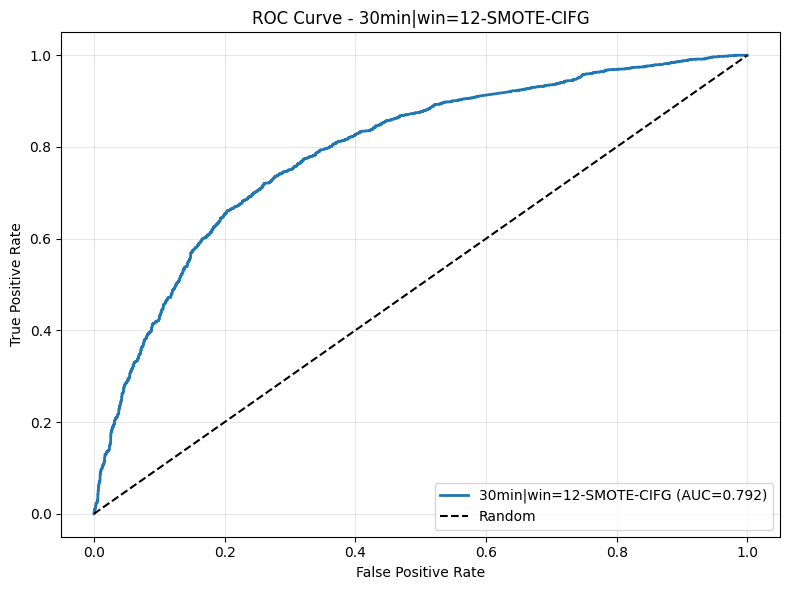

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_30min_win12-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_30min_win12-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\30min_win12-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 12164 samples, 96 batches/epoch, batch_size=128
Validation: 4055 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6569 | Val Loss: 0.6041 | Val Acc: 0.5166 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5935 | Val Loss: 0.5830 | Val Acc: 0.6732 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5877 | Val Loss: 0.5777 | Val Acc: 0.6688 [UNDERFITTING]
Epoch    4/500 | Train 

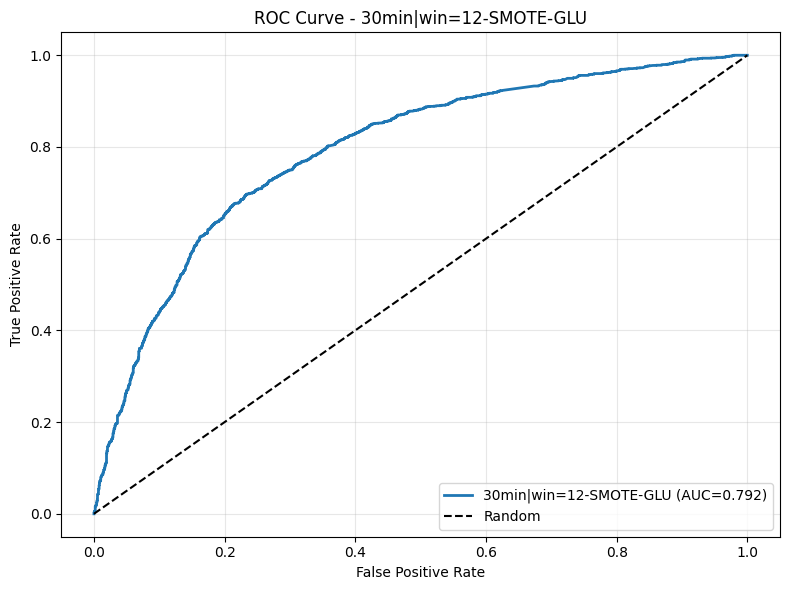

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_30min_win12-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_30min_win12-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\30min_win12-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 12164 samples, 96 batches/epoch, batch_size=128
Validation: 4055 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5883 | Val Loss: 0.5713 | Val Acc: 0.6787 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5733 | Val Loss: 0.5756 | Val Acc: 0.6466 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5776 | Val Loss: 0.5734 | Val Acc: 0.6318 [UNDERFITTING]
Epoch    4

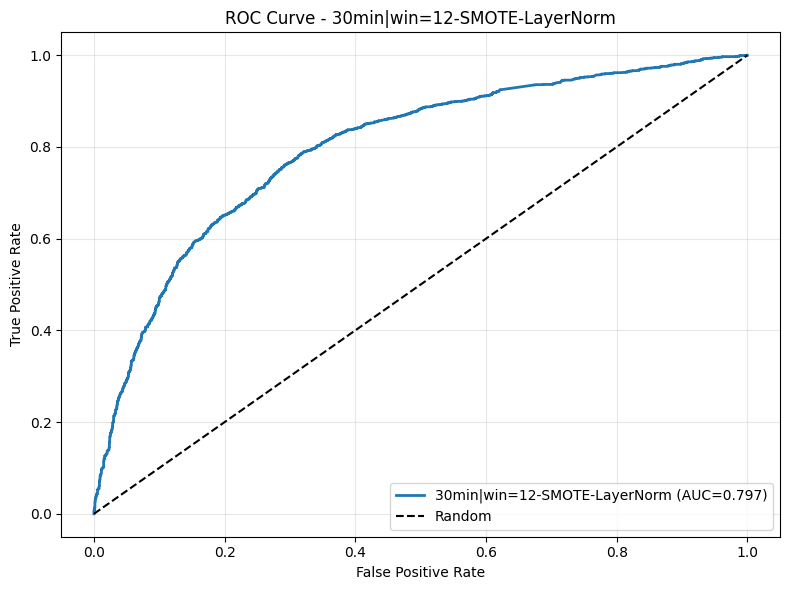

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_30min_win12-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_30min_win12-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\30min_win12-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 12164 samples, 96 batches/epoch, batch_size=128
Validation: 4055 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5979 | Val Loss: 0.5750 | Val Acc: 0.6506 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5760 | Val Loss: 0.5729 | Val Acc: 0.6890 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5783 | Val Loss: 0.5713 | Val Acc: 0.705

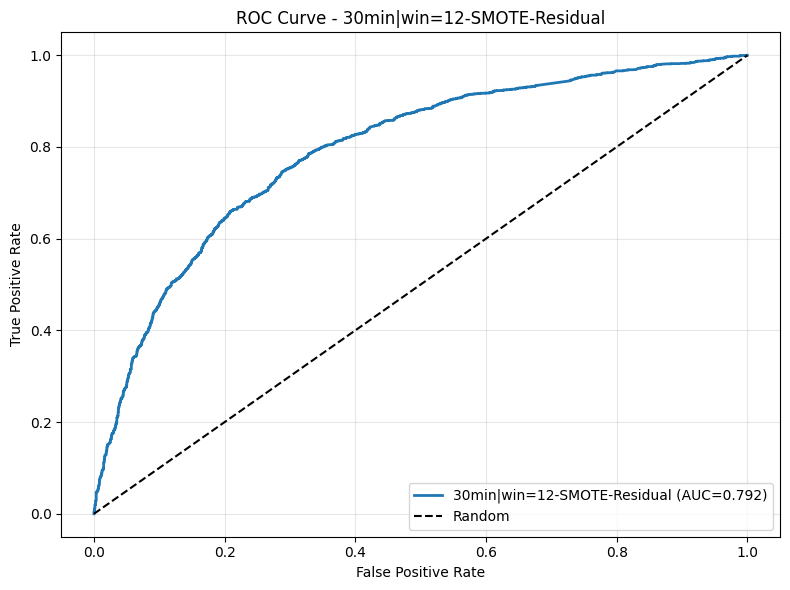

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_30min_win12-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_30min_win12-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\30min_win12-SMOTE-Residual

  Window Size: 24
    Data: 14616 samples, Class 0: 10130, Class 1: 4486

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 12156 samples, 95 batches/epoch, batch_size=128
Validation: 4052 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5990 | Val Loss: 0.5607 | Val Acc: 0.6807 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5660 | Val Loss: 0.5516 | Val Acc: 0.6915 [UNDERFITTING]
Epoch    3/500

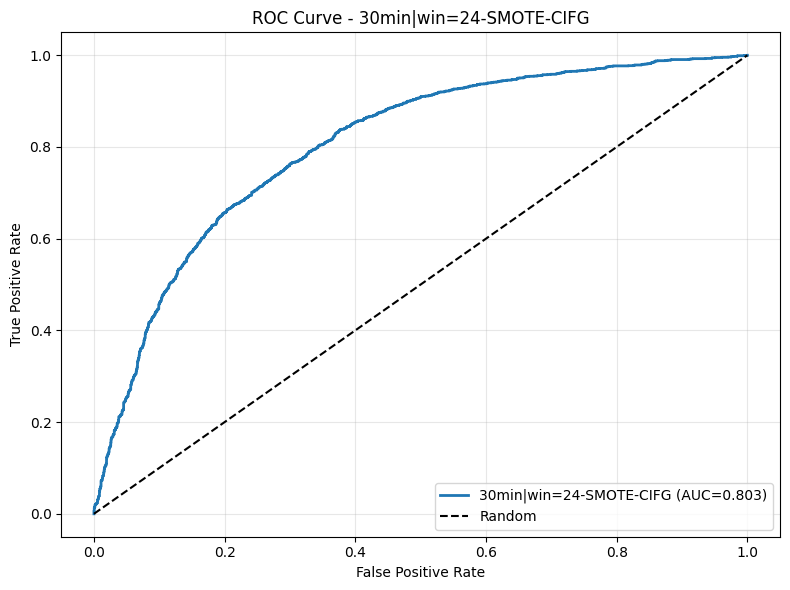

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_30min_win24-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_30min_win24-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\30min_win24-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 12156 samples, 95 batches/epoch, batch_size=128
Validation: 4052 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6375 | Val Loss: 0.5686 | Val Acc: 0.6483 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5764 | Val Loss: 0.5629 | Val Acc: 0.6562 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5693 | Val Loss: 0.5579 | Val Acc: 0.6629 [UNDERFITTING]
Epoch    4/500 | Train 

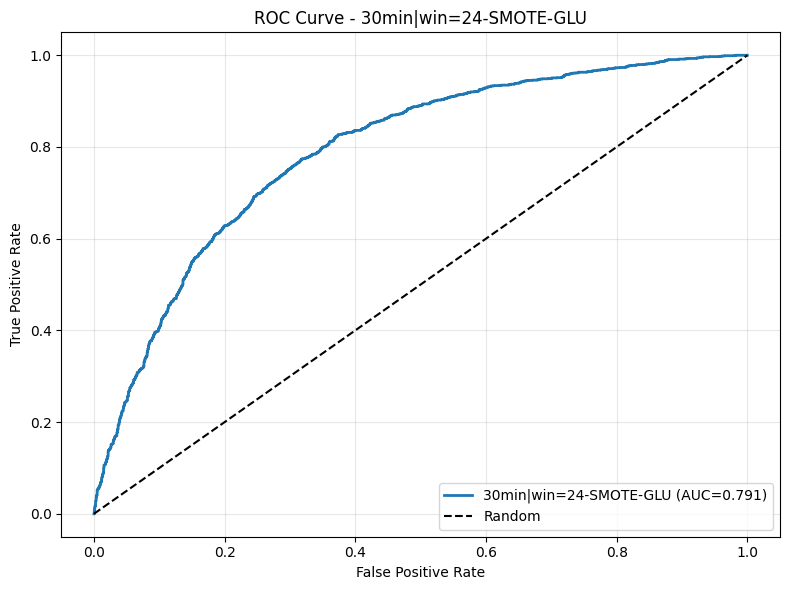

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_30min_win24-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_30min_win24-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\30min_win24-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 12156 samples, 95 batches/epoch, batch_size=128
Validation: 4052 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: nan | Val Loss: nan | Val Acc: 0.5000
Epoch    2/500 | Train Loss: nan | Val Loss: nan | Val Acc: 0.5000

🛑 Early stopping triggered at epoch 3
----------------------------------------------------------------------
Final - Train Loss: nan | Val 

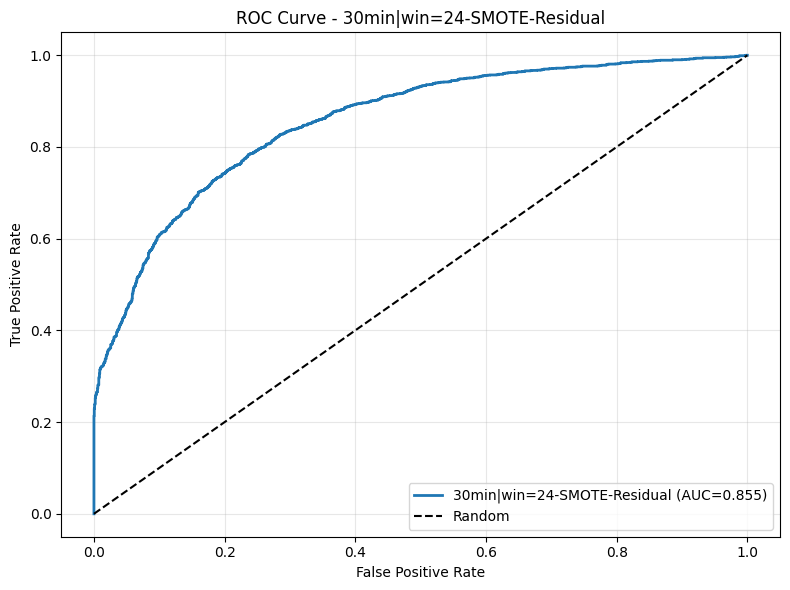

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_30min_win24-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_30min_win24-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\30min_win24-SMOTE-Residual

  Window Size: 36
    Data: 14604 samples, Class 0: 10122, Class 1: 4482

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 12146 samples, 95 batches/epoch, batch_size=128
Validation: 4049 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5912 | Val Loss: 0.5797 | Val Acc: 0.6814 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5649 | Val Loss: 0.5753 | Val Acc: 0.6812 [UNDERFITTING]
Epoch    3/500

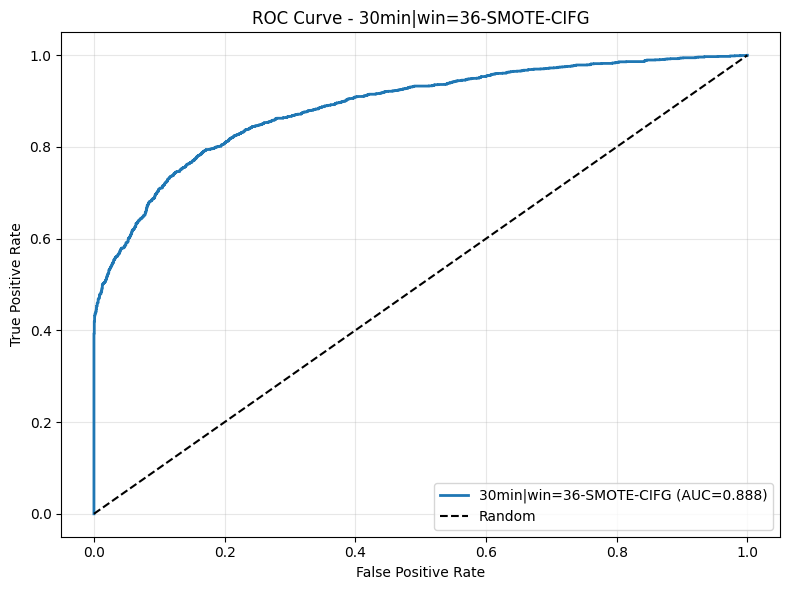

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_30min_win36-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_30min_win36-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\30min_win36-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 12146 samples, 95 batches/epoch, batch_size=128
Validation: 4049 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6438 | Val Loss: 0.5948 | Val Acc: 0.5614 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5741 | Val Loss: 0.5777 | Val Acc: 0.6342 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5662 | Val Loss: 0.5715 | Val Acc: 0.6560 [UNDERFITTING]
Epoch    4/500 | Train 

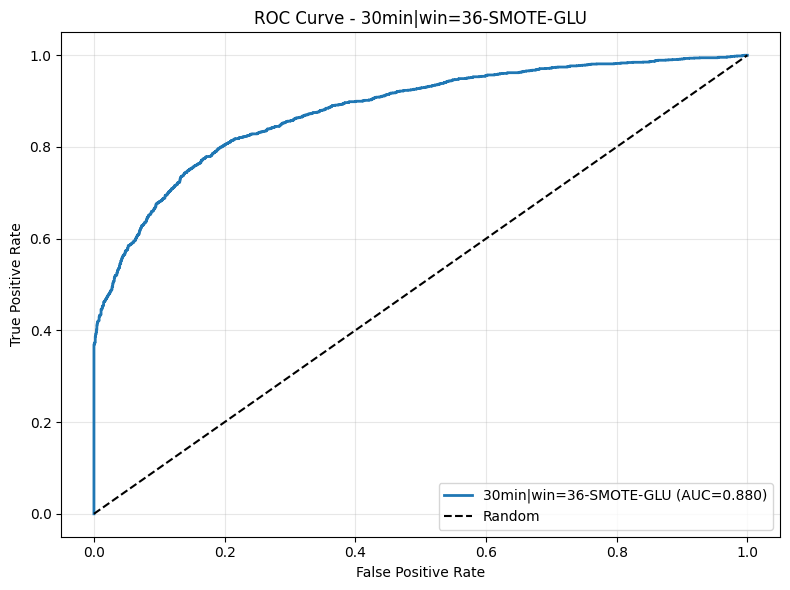

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_30min_win36-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_30min_win36-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\30min_win36-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 12146 samples, 95 batches/epoch, batch_size=128
Validation: 4049 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5940 | Val Loss: 0.5775 | Val Acc: 0.6530 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5589 | Val Loss: 0.5678 | Val Acc: 0.6858 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5530 | Val Loss: 0.5607 | Val Acc: 0.6918 [UNDERFITTING]
Epoch    4

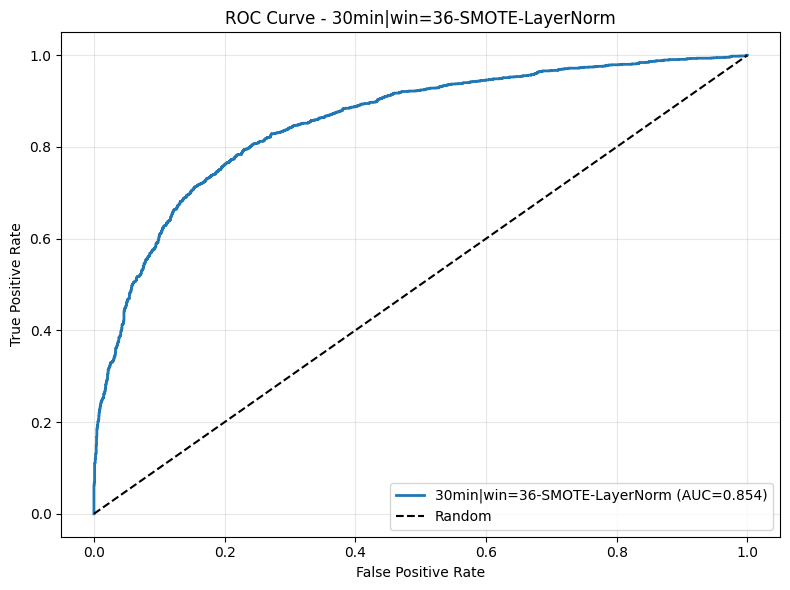

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_30min_win36-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_30min_win36-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\30min_win36-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 12146 samples, 95 batches/epoch, batch_size=128
Validation: 4049 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5797 | Val Loss: 0.5693 | Val Acc: 0.6597 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5591 | Val Loss: 0.5596 | Val Acc: 0.6804 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5501 | Val Loss: 0.5548 | Val Acc: 0.681

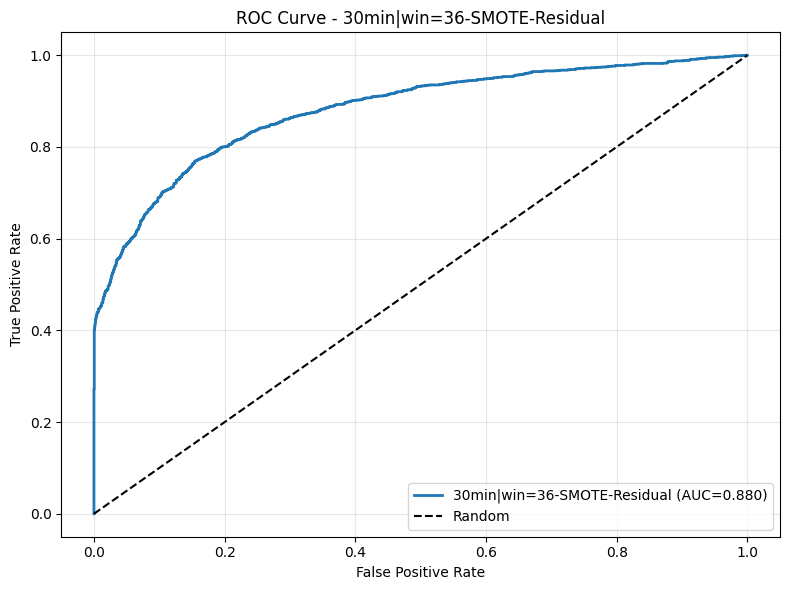

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_30min_win36-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_30min_win36-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\30min_win36-SMOTE-Residual

  Window Size: 48
    Data: 14592 samples, Class 0: 10112, Class 1: 4480

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6009 | Val Loss: 0.5811 | Val Acc: 0.6527 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5684 | Val Loss: 0.5508 | Val Acc: 0.7006 [UNDERFITTING]
Epoch    3/500

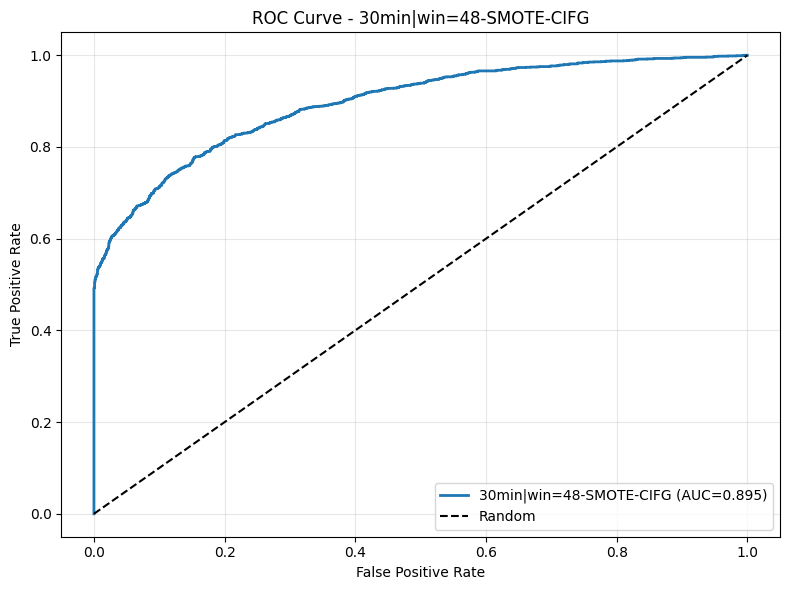

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_30min_win48-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_30min_win48-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\30min_win48-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6296 | Val Loss: 0.5679 | Val Acc: 0.6418 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5755 | Val Loss: 0.5600 | Val Acc: 0.6737 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5666 | Val Loss: 0.5452 | Val Acc: 0.6989 [UNDERFITTING]
Epoch    4/500 | Train 

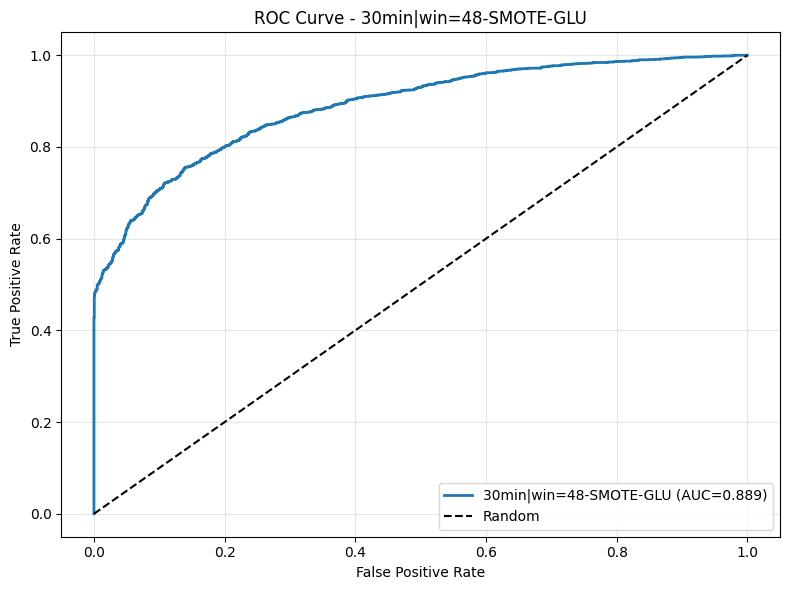

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_30min_win48-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_30min_win48-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\30min_win48-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 12134 samples, 95 batches/epoch, batch_size=128
Validation: 4045 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: nan | Val Loss: nan | Val Acc: 0.4999
Epoch    2/500 | Train Loss: nan | Val Loss: nan | Val Acc: 0.4999

🛑 Early stopping triggered at epoch 3
----------------------------------------------------------------------
Final - Train Loss: nan | Val 

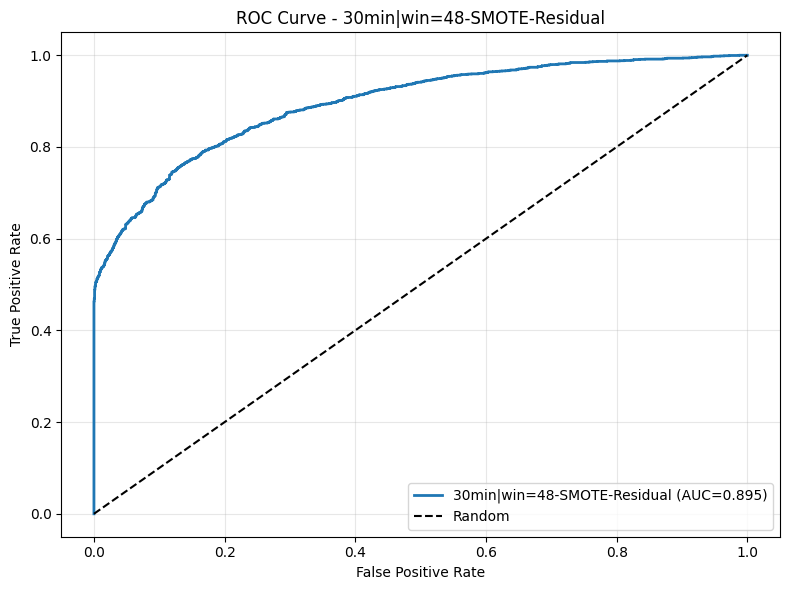

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_30min_win48-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_30min_win48-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\30min_win48-SMOTE-Residual

  Window Size: 60
    Data: 14580 samples, Class 0: 10100, Class 1: 4480

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 12120 samples, 95 batches/epoch, batch_size=128
Validation: 4040 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6005 | Val Loss: 0.5606 | Val Acc: 0.7042 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5577 | Val Loss: 0.5512 | Val Acc: 0.6864 [UNDERFITTING]
Epoch    3/500

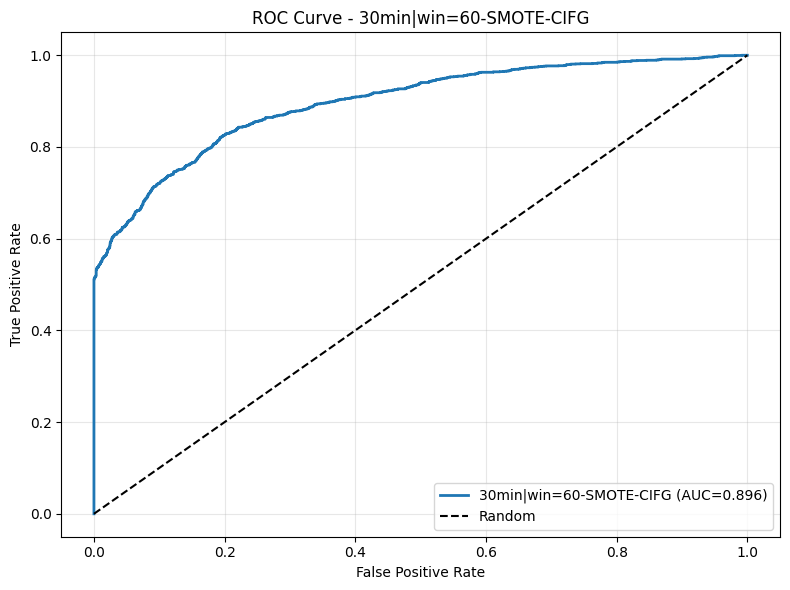

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_30min_win60-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_30min_win60-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\30min_win60-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 12120 samples, 95 batches/epoch, batch_size=128
Validation: 4040 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6222 | Val Loss: 0.5726 | Val Acc: 0.6520 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5660 | Val Loss: 0.5582 | Val Acc: 0.6990 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5530 | Val Loss: 0.5496 | Val Acc: 0.6795 [UNDERFITTING]
Epoch    4/500 | Train 

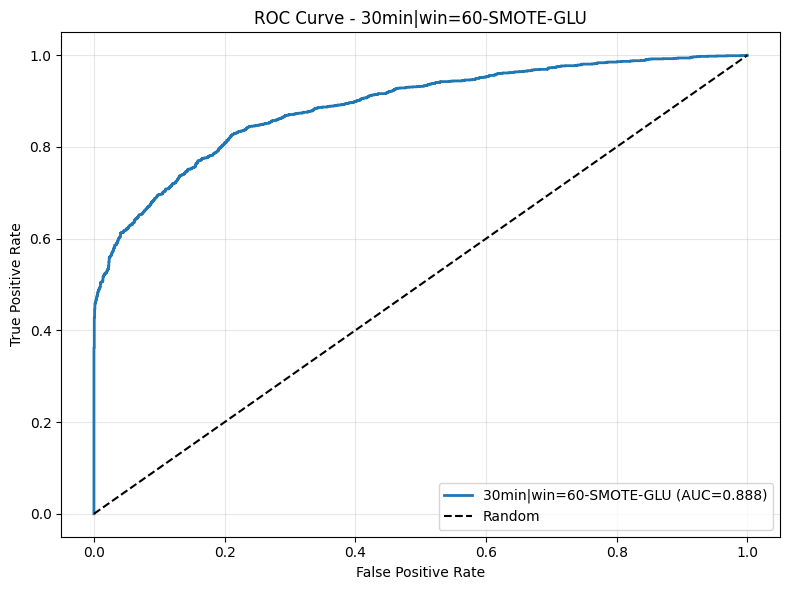

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_30min_win60-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_30min_win60-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\30min_win60-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 12120 samples, 95 batches/epoch, batch_size=128
Validation: 4040 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5991 | Val Loss: 0.5613 | Val Acc: 0.7035 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5571 | Val Loss: 0.5491 | Val Acc: 0.6891 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5442 | Val Loss: 0.5435 | Val Acc: 0.7092 [UNDERFITTING]
Epoch    4

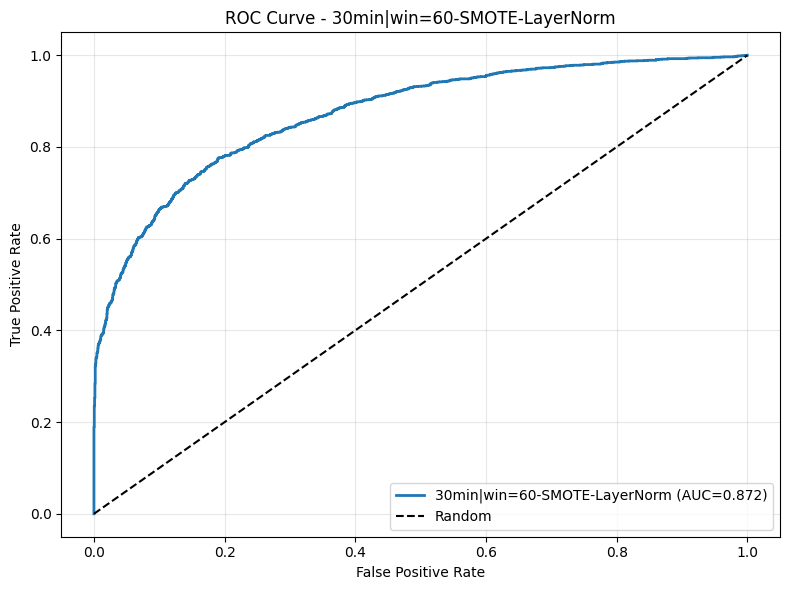

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_30min_win60-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_30min_win60-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\30min_win60-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 12120 samples, 95 batches/epoch, batch_size=128
Validation: 4040 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5906 | Val Loss: 0.5580 | Val Acc: 0.6950 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5467 | Val Loss: 0.5340 | Val Acc: 0.6943 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5267 | Val Loss: 0.5117 | Val Acc: 0.740

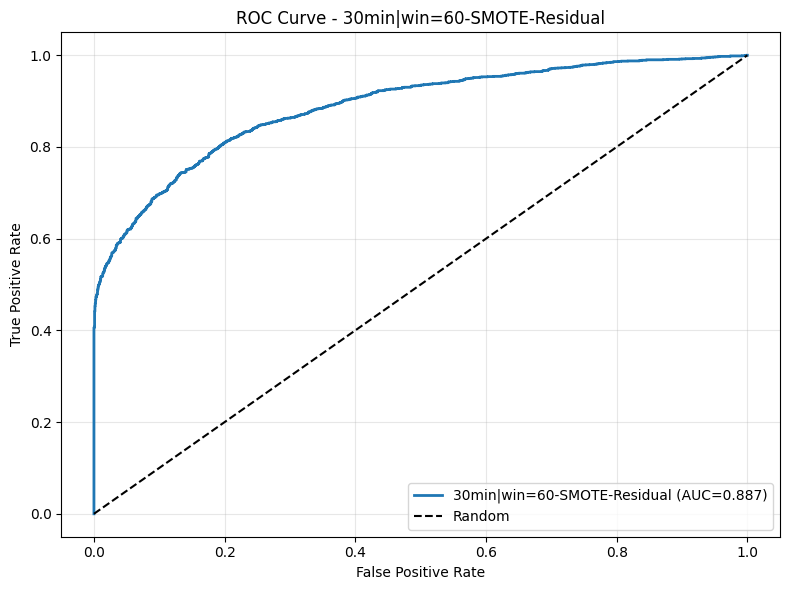

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_30min_win60-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_30min_win60-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\30min_win60-SMOTE-Residual

Sampling Period: 1h

  Window Size: 12
    Data: 7309 samples, Class 0: 3988, Class 1: 3321

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 4785 samples, 38 batches/epoch, batch_size=128
Validation: 1595 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6343 | Val Loss: 0.6116 | Val Acc: 0.6263 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5881 | Val Loss: 0.6045 | Val Acc: 0.6282 [UNDERFITTI

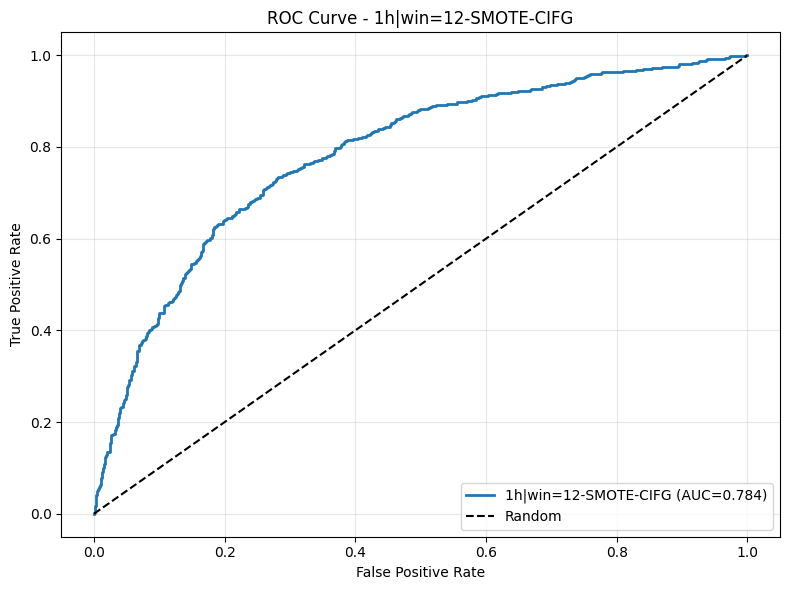

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_1h_win12-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_1h_win12-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\1h_win12-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 4785 samples, 38 batches/epoch, batch_size=128
Validation: 1595 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6725 | Val Loss: 0.6482 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6111 | Val Loss: 0.6055 | Val Acc: 0.5737 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5959 | Val Loss: 0.6018 | Val Acc: 0.6219 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.58

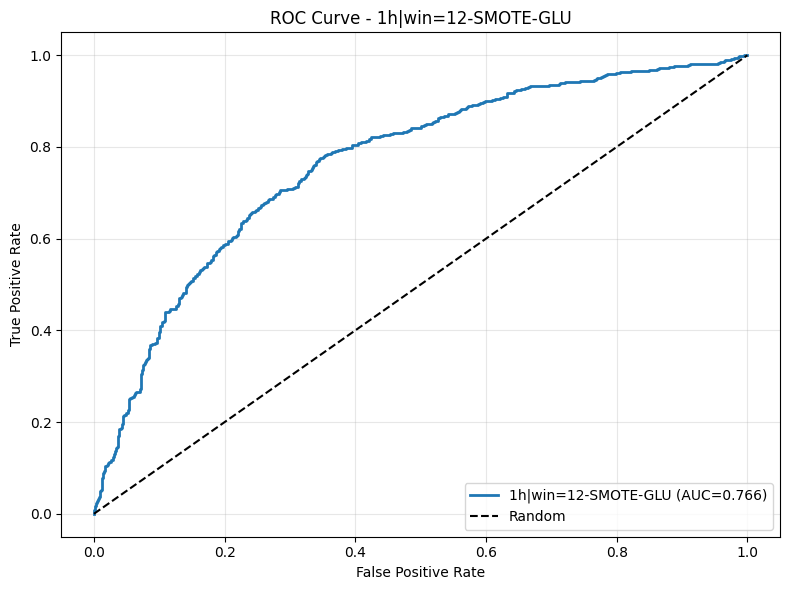

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_1h_win12-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_1h_win12-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\1h_win12-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 4785 samples, 38 batches/epoch, batch_size=128
Validation: 1595 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5959 | Val Loss: 0.5889 | Val Acc: 0.6282 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5756 | Val Loss: 0.5893 | Val Acc: 0.6696 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5726 | Val Loss: 0.5871 | Val Acc: 0.6226 [UNDERFITTING]
Epoch    4/500 | Tra

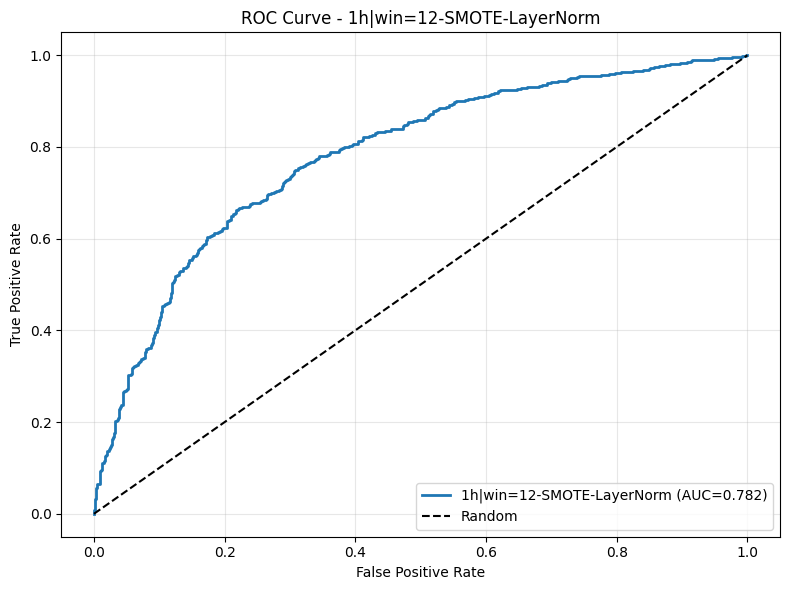

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_1h_win12-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_1h_win12-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\1h_win12-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 4785 samples, 38 batches/epoch, batch_size=128
Validation: 1595 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6138 | Val Loss: 0.6072 | Val Acc: 0.6451 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5891 | Val Loss: 0.6123 | Val Acc: 0.5925 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5854 | Val Loss: 0.5930 | Val Acc: 0.6288 [UNDERFI

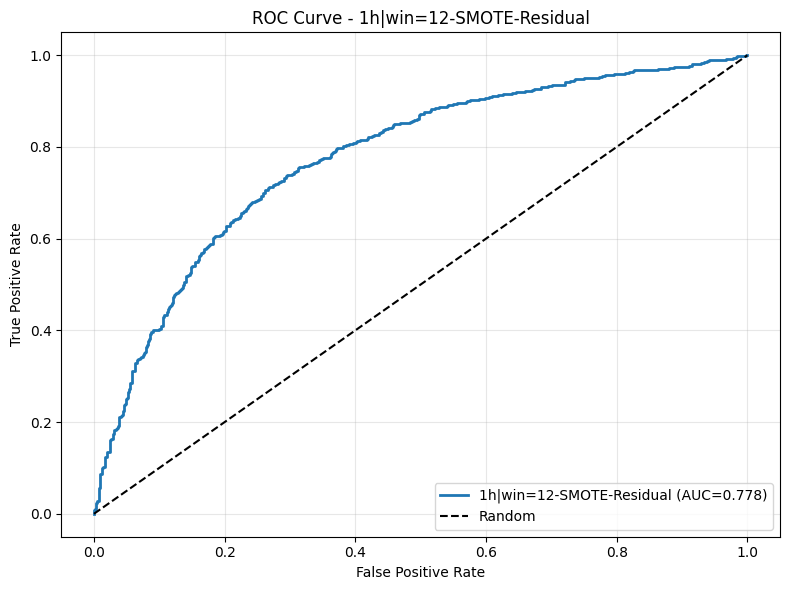

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_1h_win12-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_1h_win12-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\1h_win12-SMOTE-Residual

  Window Size: 24
    Data: 7297 samples, Class 0: 3981, Class 1: 3316

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 4776 samples, 38 batches/epoch, batch_size=128
Validation: 1593 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6322 | Val Loss: 0.5990 | Val Acc: 0.6510 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5814 | Val Loss: 0.5827 | Val Acc: 0.6485 [UNDERFITTING]
Epoch    3/500 | Train Los

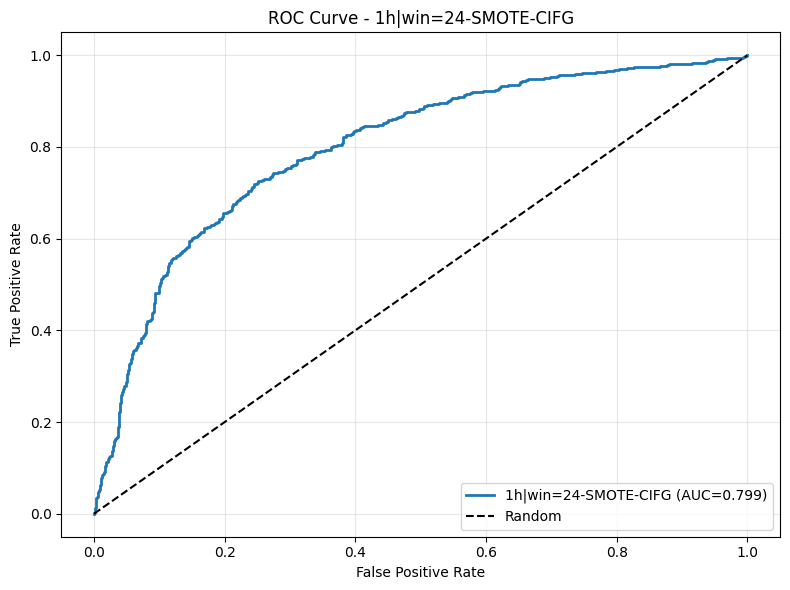

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_1h_win24-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_1h_win24-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\1h_win24-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 4776 samples, 38 batches/epoch, batch_size=128
Validation: 1593 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6809 | Val Loss: 0.6577 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6118 | Val Loss: 0.5986 | Val Acc: 0.5612 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5832 | Val Loss: 0.5849 | Val Acc: 0.6246 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.57

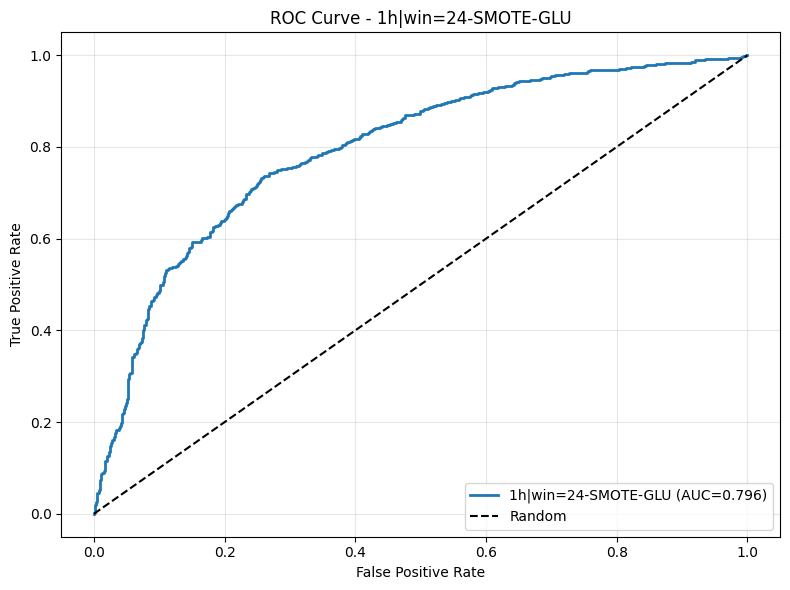

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_1h_win24-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_1h_win24-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\1h_win24-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 4776 samples, 38 batches/epoch, batch_size=128
Validation: 1593 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5935 | Val Loss: 0.5858 | Val Acc: 0.6485 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5524 | Val Loss: 0.5675 | Val Acc: 0.6635 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5456 | Val Loss: 0.5723 | Val Acc: 0.6516 [UNDERFITTING]
Epoch    4/500 | Tra

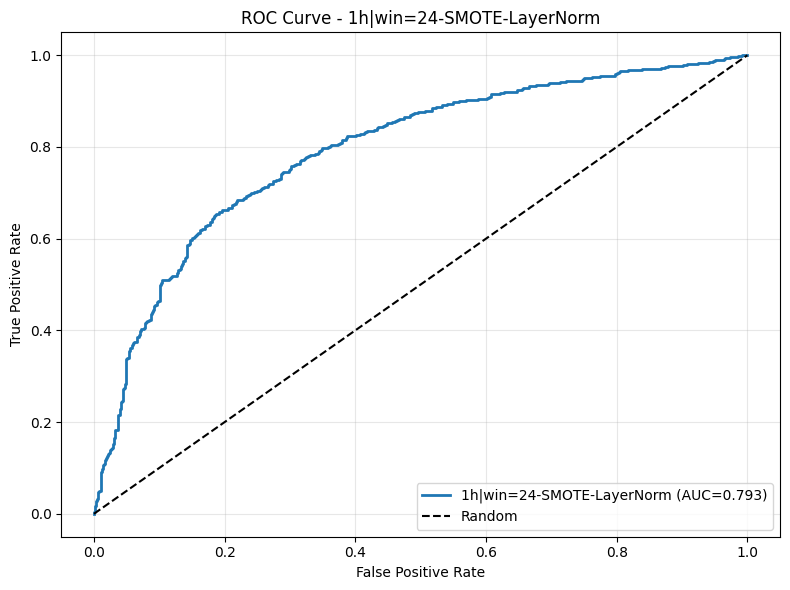

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_1h_win24-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_1h_win24-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\1h_win24-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 4776 samples, 38 batches/epoch, batch_size=128
Validation: 1593 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6026 | Val Loss: 0.5832 | Val Acc: 0.6560 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5741 | Val Loss: 0.5802 | Val Acc: 0.6208 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5593 | Val Loss: 0.5794 | Val Acc: 0.6792 [UNDERFI

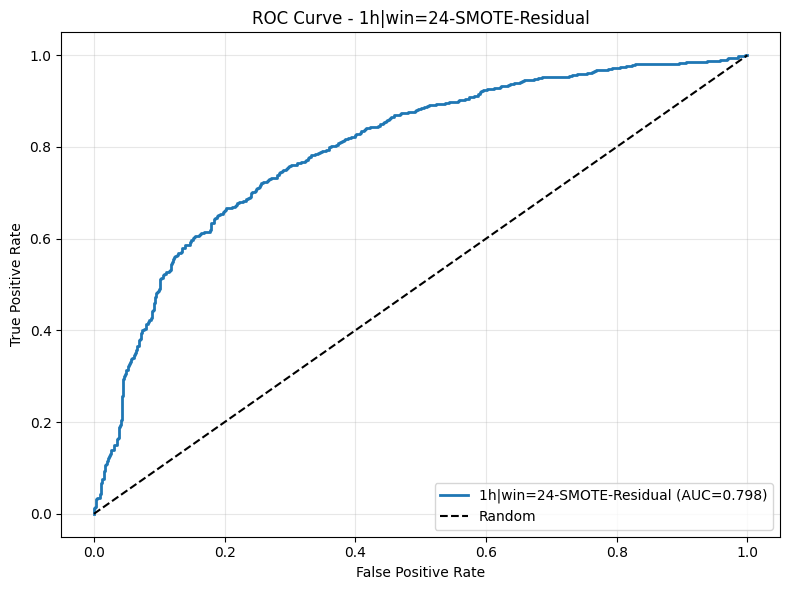

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_1h_win24-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_1h_win24-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\1h_win24-SMOTE-Residual

  Window Size: 36
    Data: 7285 samples, Class 0: 3973, Class 1: 3312

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 4767 samples, 38 batches/epoch, batch_size=128
Validation: 1589 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6327 | Val Loss: 0.5672 | Val Acc: 0.7149 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5666 | Val Loss: 0.5574 | Val Acc: 0.6973 [UNDERFITTING]
Epoch    3/500 | Train Los

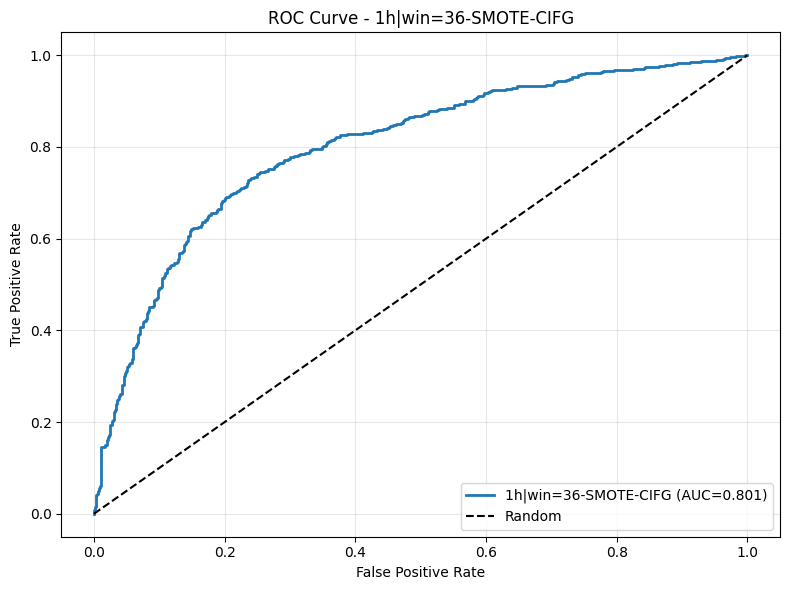

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_1h_win36-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_1h_win36-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\1h_win36-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 4767 samples, 38 batches/epoch, batch_size=128
Validation: 1589 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6750 | Val Loss: 0.6458 | Val Acc: 0.4997 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5939 | Val Loss: 0.5807 | Val Acc: 0.5941 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5736 | Val Loss: 0.5586 | Val Acc: 0.6941 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.56

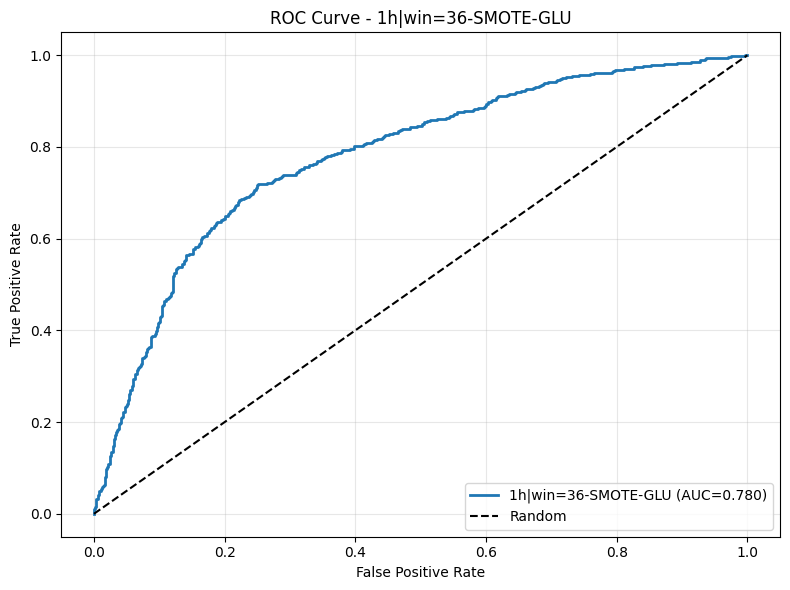

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_1h_win36-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_1h_win36-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\1h_win36-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 4767 samples, 38 batches/epoch, batch_size=128
Validation: 1589 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6104 | Val Loss: 0.5785 | Val Acc: 0.6067 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5675 | Val Loss: 0.5570 | Val Acc: 0.7030 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5559 | Val Loss: 0.5512 | Val Acc: 0.6967 [UNDERFITTING]
Epoch    4/500 | Tra

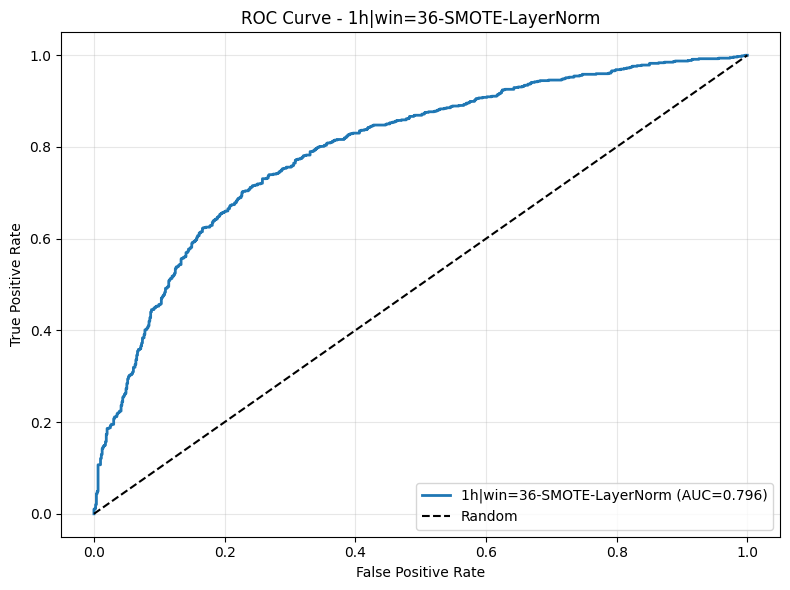

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_1h_win36-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_1h_win36-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\1h_win36-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 4767 samples, 38 batches/epoch, batch_size=128
Validation: 1589 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.5938 | Val Loss: 0.5751 | Val Acc: 0.6639 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5621 | Val Loss: 0.5630 | Val Acc: 0.7042 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5493 | Val Loss: 0.5548 | Val Acc: 0.6967 [UNDERFI

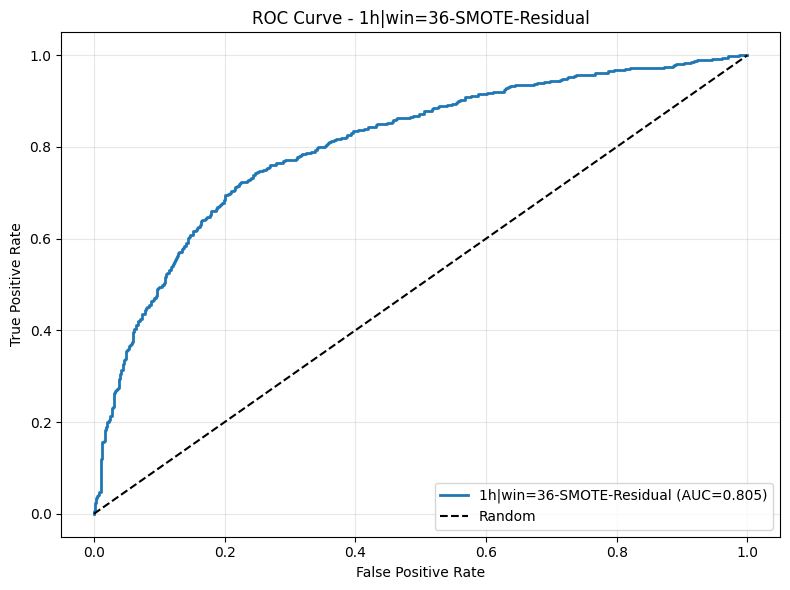

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_1h_win36-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_1h_win36-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\1h_win36-SMOTE-Residual

  Window Size: 48
    Data: 7273 samples, Class 0: 3967, Class 1: 3306

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 4760 samples, 38 batches/epoch, batch_size=128
Validation: 1587 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6343 | Val Loss: 0.5778 | Val Acc: 0.6679 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5703 | Val Loss: 0.5778 | Val Acc: 0.6503 [UNDERFITTING]
Epoch    3/500 | Train Los

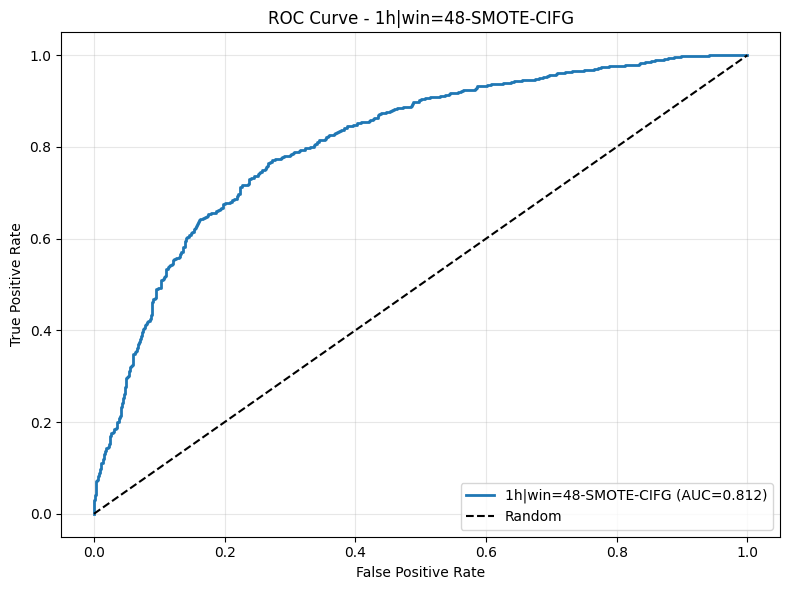

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_1h_win48-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_1h_win48-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\1h_win48-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 4760 samples, 38 batches/epoch, batch_size=128
Validation: 1587 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6775 | Val Loss: 0.6492 | Val Acc: 0.5003 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5995 | Val Loss: 0.5770 | Val Acc: 0.6371 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5834 | Val Loss: 0.5721 | Val Acc: 0.6490 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.57

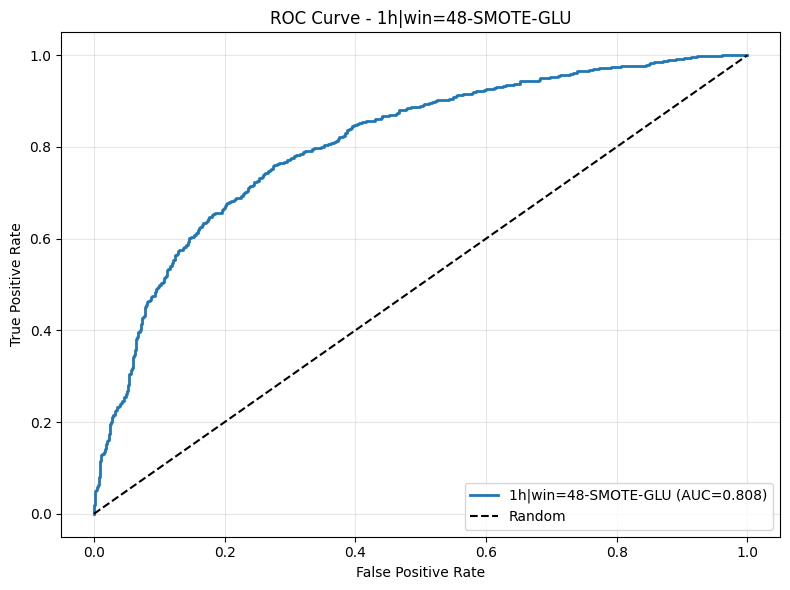

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_1h_win48-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_1h_win48-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\1h_win48-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 4760 samples, 38 batches/epoch, batch_size=128
Validation: 1587 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6238 | Val Loss: 0.5842 | Val Acc: 0.6226 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5677 | Val Loss: 0.5591 | Val Acc: 0.6604 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5585 | Val Loss: 0.5610 | Val Acc: 0.6679 [UNDERFITTING]
Epoch    4/500 | Tra

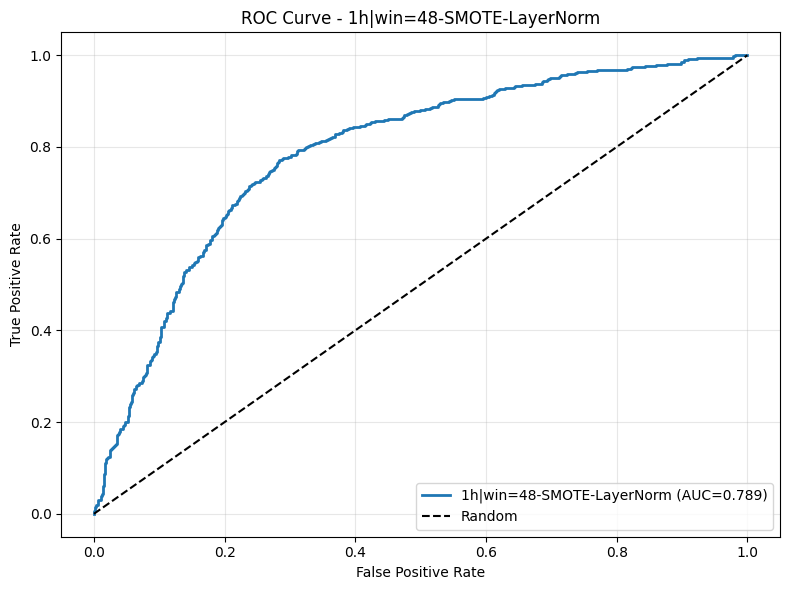

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_1h_win48-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_1h_win48-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\1h_win48-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 4760 samples, 38 batches/epoch, batch_size=128
Validation: 1587 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6326 | Val Loss: 0.5859 | Val Acc: 0.6793 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5697 | Val Loss: 0.5672 | Val Acc: 0.6547 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5683 | Val Loss: 0.5847 | Val Acc: 0.6547 [UNDERFI

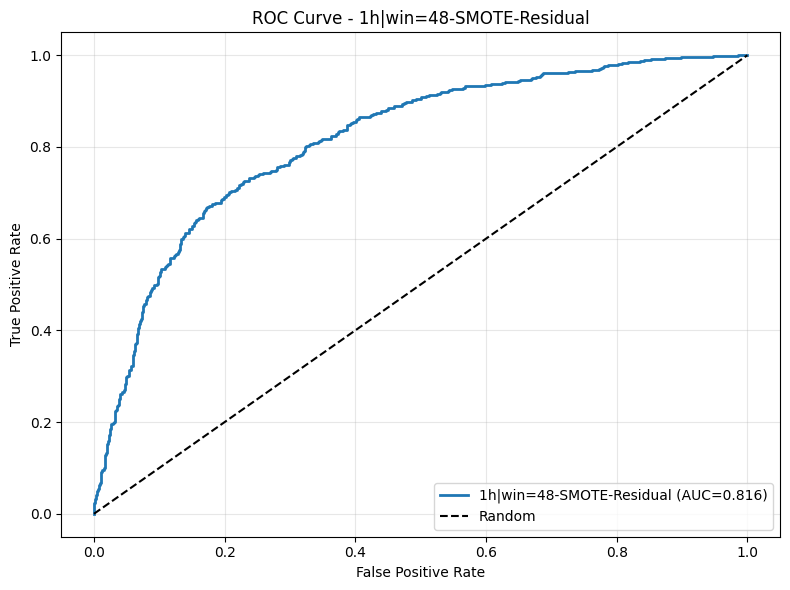

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_1h_win48-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_1h_win48-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\1h_win48-SMOTE-Residual

  Window Size: 60
    Data: 7261 samples, Class 0: 3957, Class 1: 3304

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 4748 samples, 38 batches/epoch, batch_size=128
Validation: 1583 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6401 | Val Loss: 0.5678 | Val Acc: 0.6627 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5728 | Val Loss: 0.5692 | Val Acc: 0.6873 [UNDERFITTING]
Epoch    3/500 | Train Los

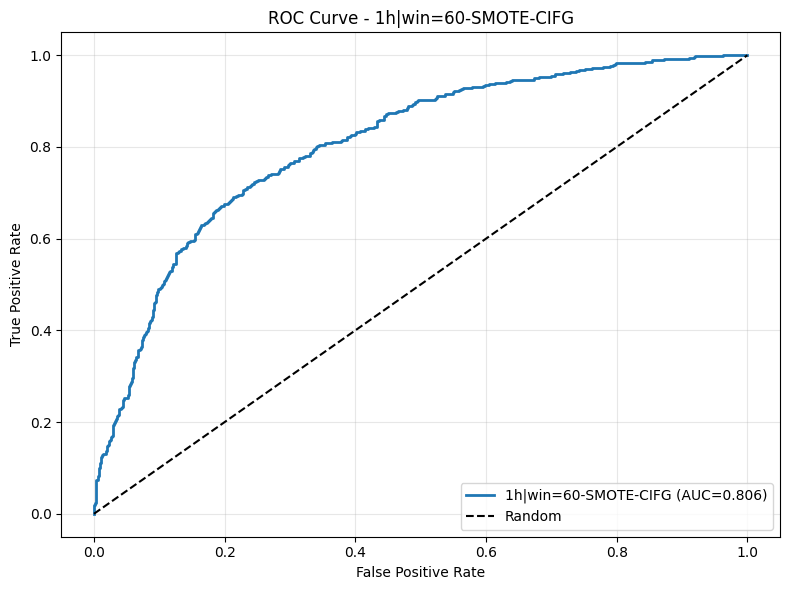

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_1h_win60-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_1h_win60-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\1h_win60-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 4748 samples, 38 batches/epoch, batch_size=128
Validation: 1583 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6672 | Val Loss: 0.6086 | Val Acc: 0.6216 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5837 | Val Loss: 0.5507 | Val Acc: 0.6835 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5673 | Val Loss: 0.5450 | Val Acc: 0.6696 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.56

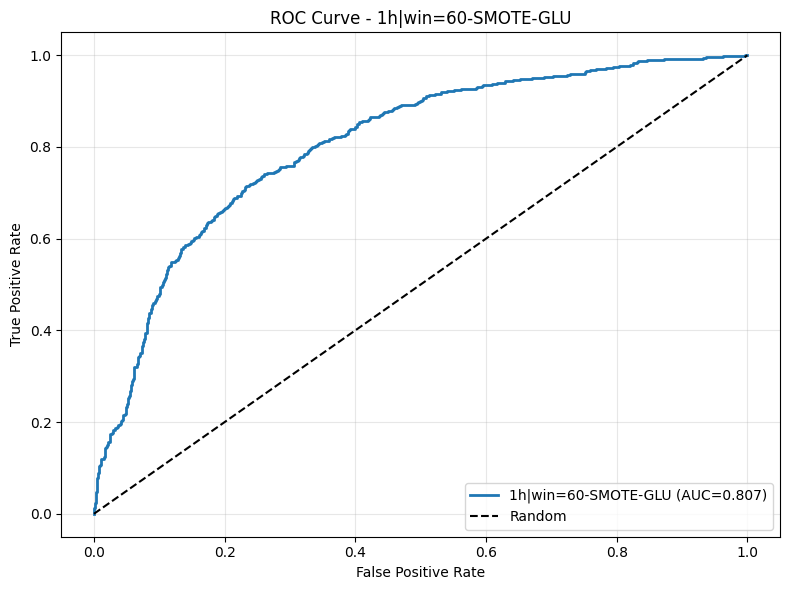

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_1h_win60-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_1h_win60-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\1h_win60-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 4748 samples, 38 batches/epoch, batch_size=128
Validation: 1583 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6157 | Val Loss: 0.6643 | Val Acc: 0.6582 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5932 | Val Loss: 0.5760 | Val Acc: 0.6955 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5705 | Val Loss: 0.5536 | Val Acc: 0.6721 [UNDERFITTING]
Epoch    4/500 | Tra

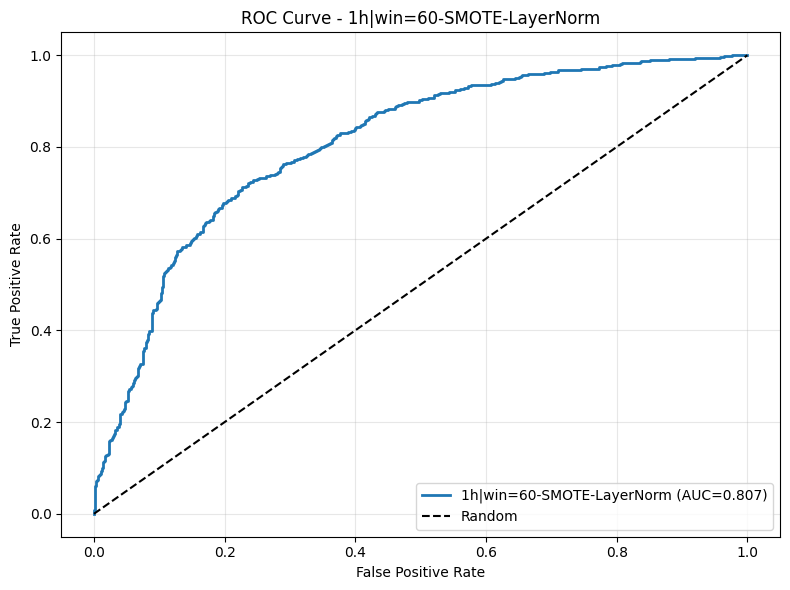

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_1h_win60-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_1h_win60-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\1h_win60-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 4748 samples, 38 batches/epoch, batch_size=128
Validation: 1583 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6113 | Val Loss: 0.5632 | Val Acc: 0.6677 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5721 | Val Loss: 0.5450 | Val Acc: 0.6684 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5591 | Val Loss: 0.5503 | Val Acc: 0.6380 [UNDERFI

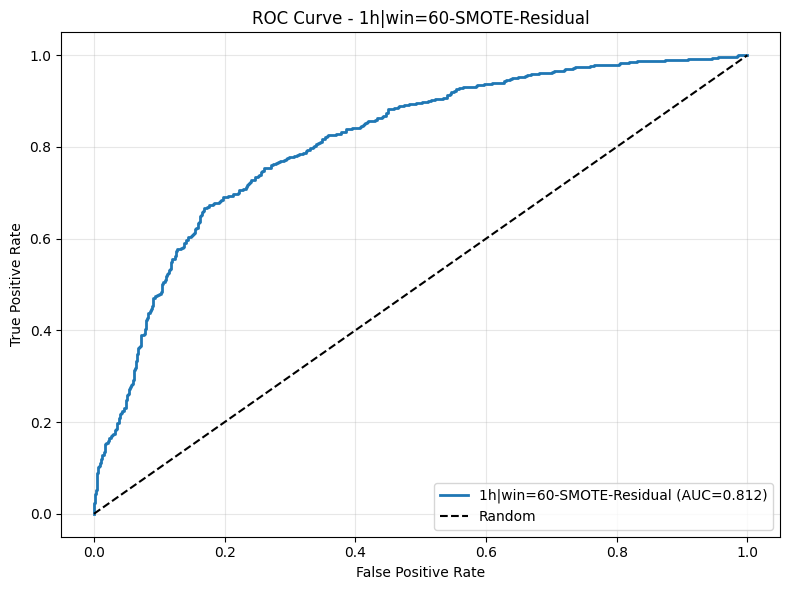

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_1h_win60-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_1h_win60-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\1h_win60-SMOTE-Residual

Sampling Period: 2h

  Window Size: 12
    Data: 3649 samples, Class 0: 1417, Class 1: 2232

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 2678 samples, 21 batches/epoch, batch_size=128
Validation: 893 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6849 | Val Loss: 0.6714 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6458 | Val Loss: 0.6133 | Val Acc: 0.6002 [UNDERFITTING]
Epoch 

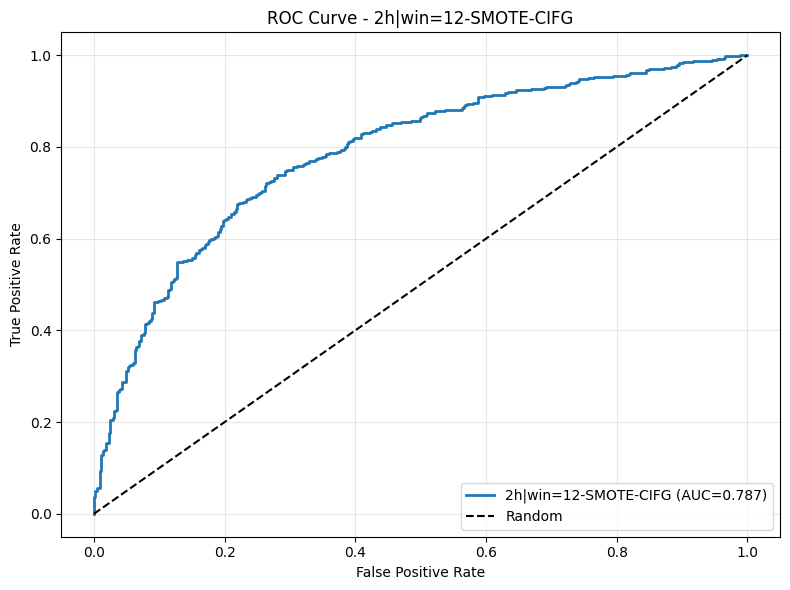

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_2h_win12-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_2h_win12-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\2h_win12-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 2678 samples, 21 batches/epoch, batch_size=128
Validation: 893 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6924 | Val Loss: 0.6872 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6811 | Val Loss: 0.6726 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.6603 | Val Loss: 0.6381 | Val Acc: 0.5263 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.628

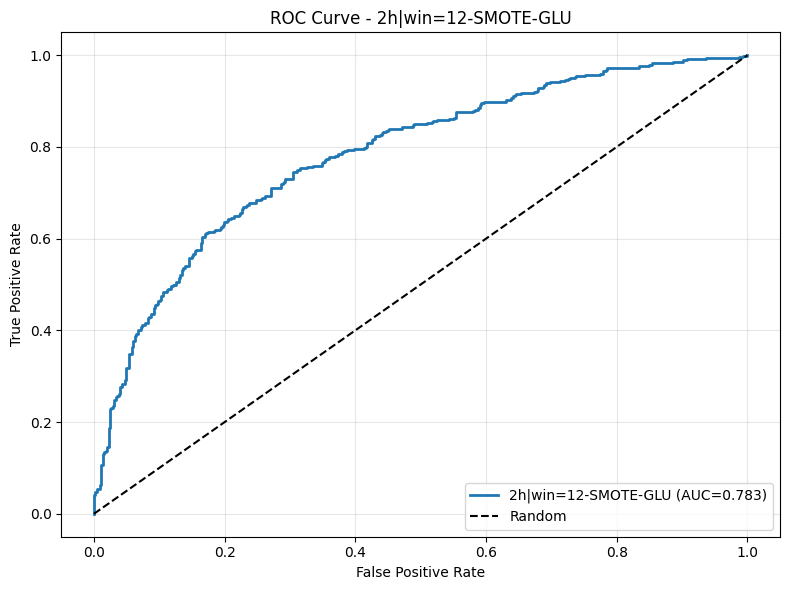

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_2h_win12-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_2h_win12-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\2h_win12-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 2678 samples, 21 batches/epoch, batch_size=128
Validation: 893 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6151 | Val Loss: 0.5829 | Val Acc: 0.6428 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5715 | Val Loss: 0.5639 | Val Acc: 0.6786 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5589 | Val Loss: 0.5656 | Val Acc: 0.6853 [UNDERFITTING]
Epoch    4/500 | Trai

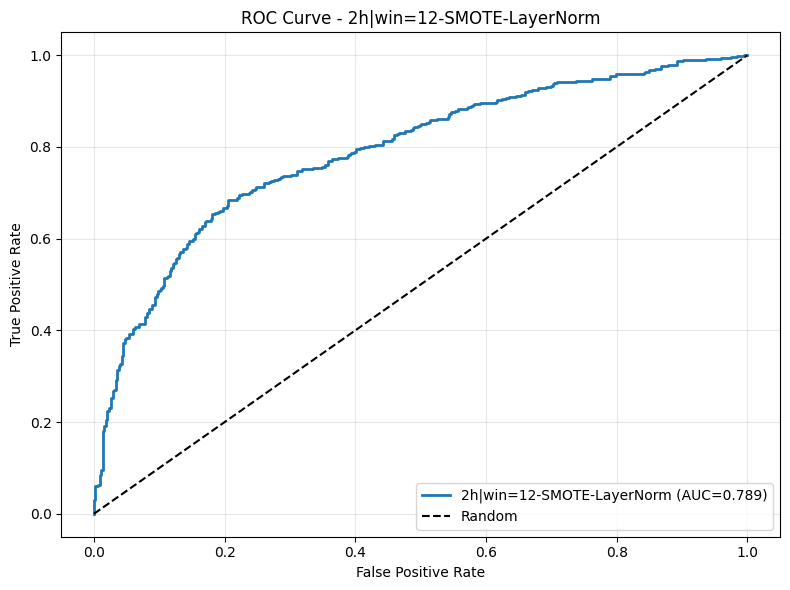

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_2h_win12-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_2h_win12-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\2h_win12-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 2678 samples, 21 batches/epoch, batch_size=128
Validation: 893 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6593 | Val Loss: 0.6329 | Val Acc: 0.5801 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6121 | Val Loss: 0.6052 | Val Acc: 0.6148 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5986 | Val Loss: 0.5957 | Val Acc: 0.6551 [UNDERFIT

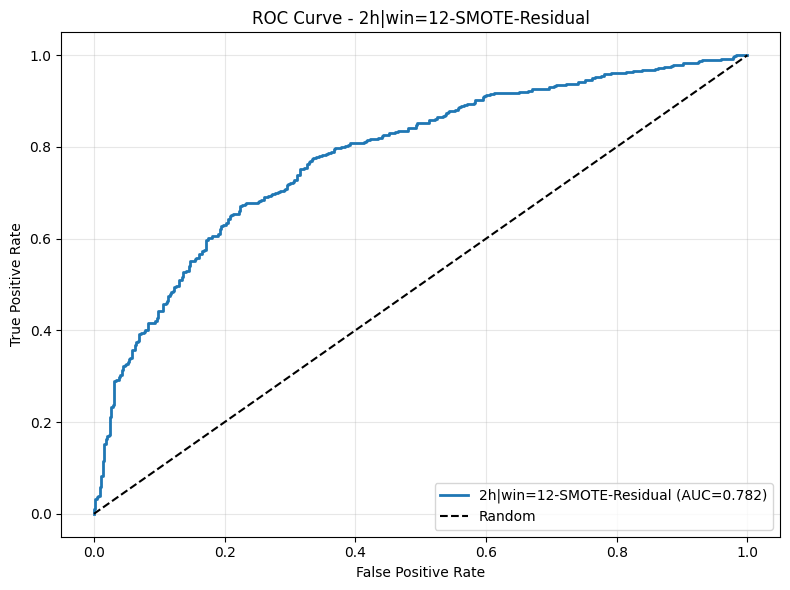

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_2h_win12-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_2h_win12-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\2h_win12-SMOTE-Residual

  Window Size: 24
    Data: 3637 samples, Class 0: 1412, Class 1: 2225

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 2670 samples, 21 batches/epoch, batch_size=128
Validation: 890 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6811 | Val Loss: 0.6645 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6141 | Val Loss: 0.6037 | Val Acc: 0.6708 [UNDERFITTING]
Epoch    3/500 | Train Loss

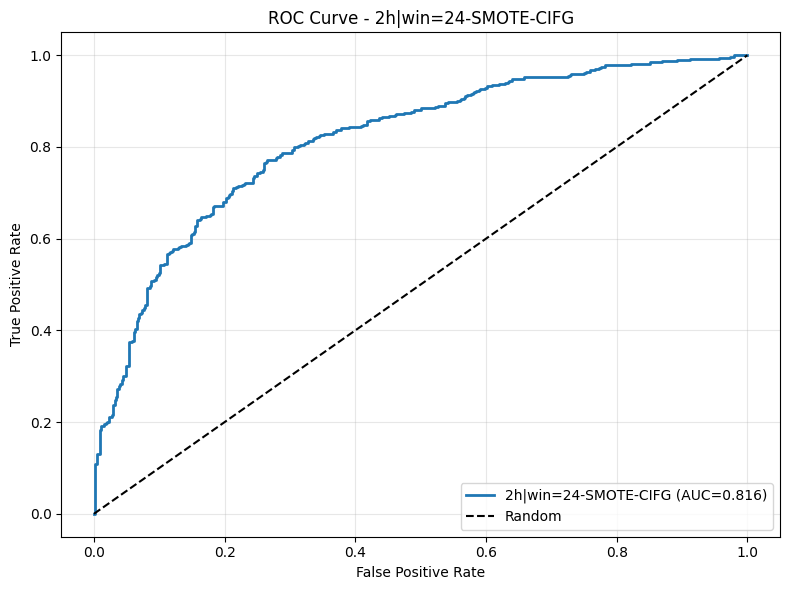

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_2h_win24-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_2h_win24-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\2h_win24-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 2670 samples, 21 batches/epoch, batch_size=128
Validation: 890 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6906 | Val Loss: 0.6865 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6814 | Val Loss: 0.6746 | Val Acc: 0.5000 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.6455 | Val Loss: 0.6316 | Val Acc: 0.6584 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.592

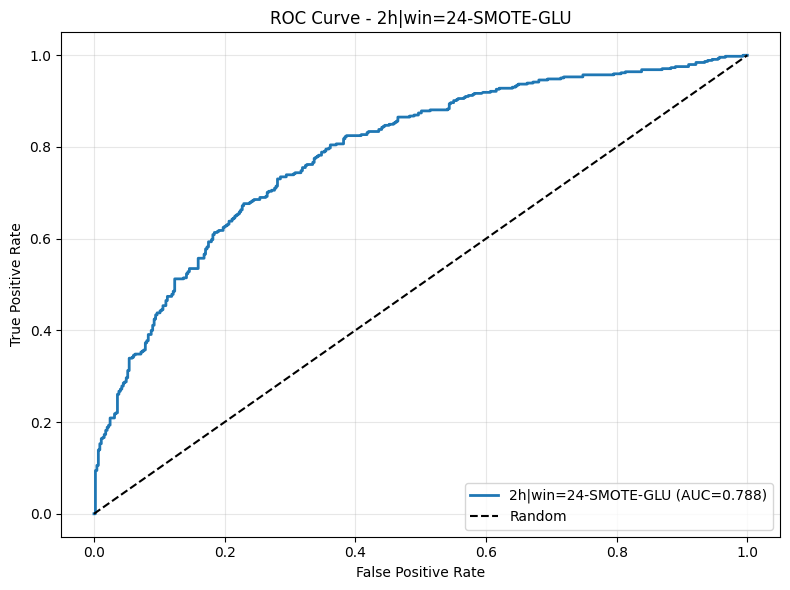

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_2h_win24-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_2h_win24-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\2h_win24-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 2670 samples, 21 batches/epoch, batch_size=128
Validation: 890 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6035 | Val Loss: 0.5718 | Val Acc: 0.6270 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5594 | Val Loss: 0.5710 | Val Acc: 0.6663 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5549 | Val Loss: 0.5705 | Val Acc: 0.6831 [UNDERFITTING]
Epoch    4/500 | Trai

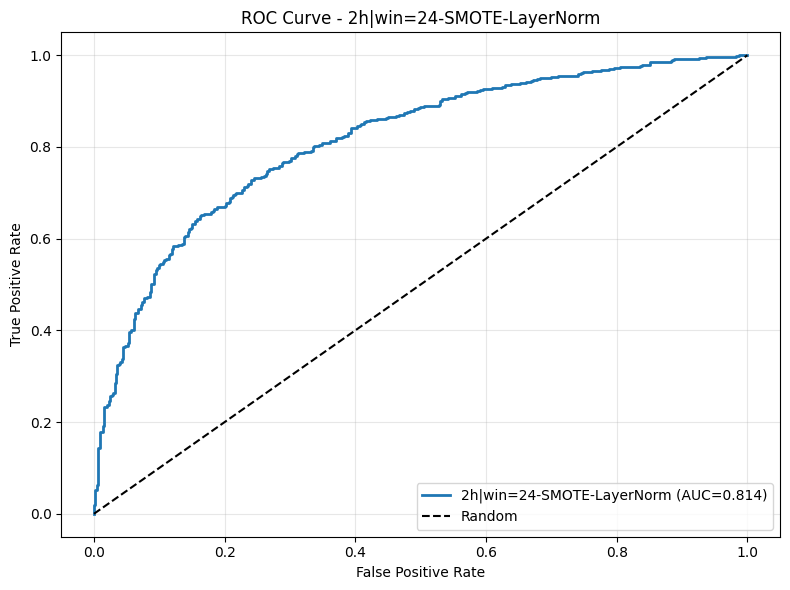

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_2h_win24-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_2h_win24-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\2h_win24-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 2670 samples, 21 batches/epoch, batch_size=128
Validation: 890 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6542 | Val Loss: 0.6429 | Val Acc: 0.6067 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5863 | Val Loss: 0.5856 | Val Acc: 0.6685 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5616 | Val Loss: 0.5886 | Val Acc: 0.6000 [UNDERFIT

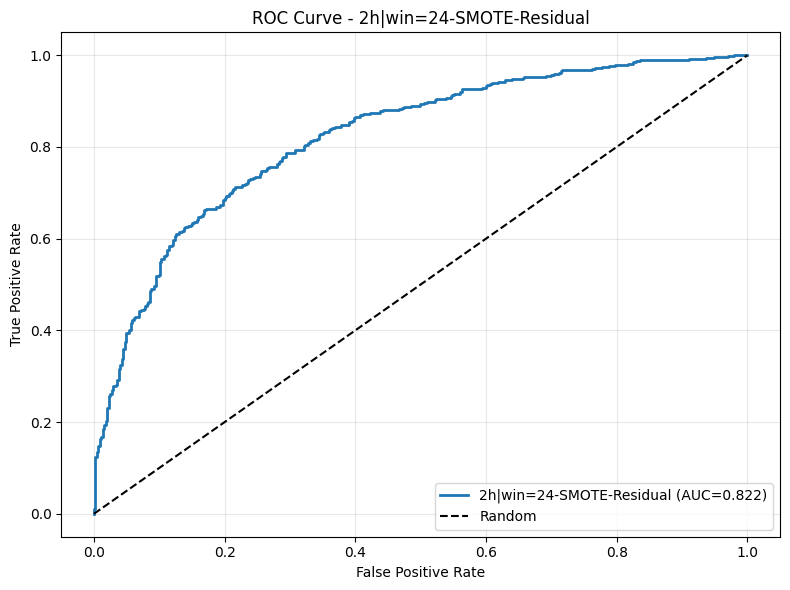

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_2h_win24-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_2h_win24-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\2h_win24-SMOTE-Residual

  Window Size: 36
    Data: 3625 samples, Class 0: 1407, Class 1: 2218

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 2661 samples, 21 batches/epoch, batch_size=128
Validation: 887 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6858 | Val Loss: 0.6711 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6342 | Val Loss: 0.5839 | Val Acc: 0.6404 [UNDERFITTING]
Epoch    3/500 | Train Loss

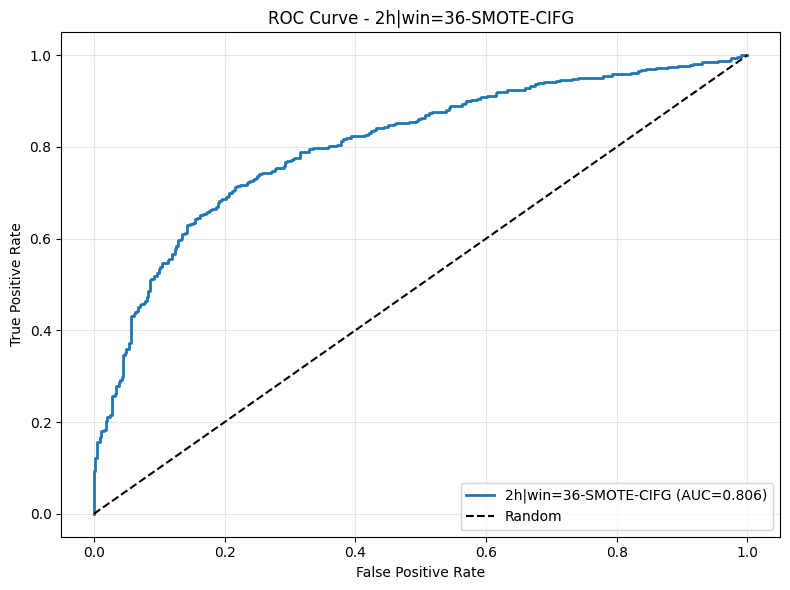

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_2h_win36-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_2h_win36-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\2h_win36-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 2661 samples, 21 batches/epoch, batch_size=128
Validation: 887 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6896 | Val Loss: 0.6838 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6762 | Val Loss: 0.6677 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.6276 | Val Loss: 0.5968 | Val Acc: 0.5874 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.588

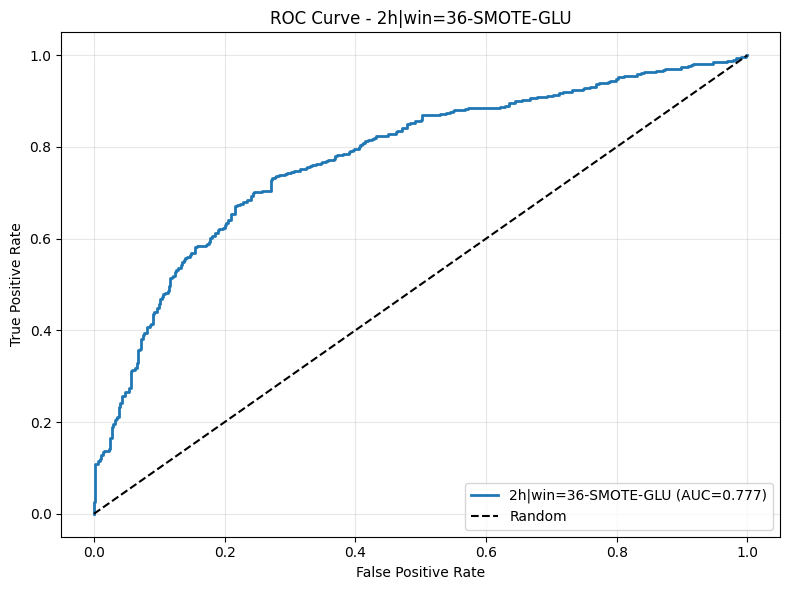

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_2h_win36-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_2h_win36-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\2h_win36-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 2661 samples, 21 batches/epoch, batch_size=128
Validation: 887 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6579 | Val Loss: 0.6061 | Val Acc: 0.5547 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5907 | Val Loss: 0.5847 | Val Acc: 0.5964 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5576 | Val Loss: 0.5532 | Val Acc: 0.6607 [UNDERFITTING]
Epoch    4/500 | Trai

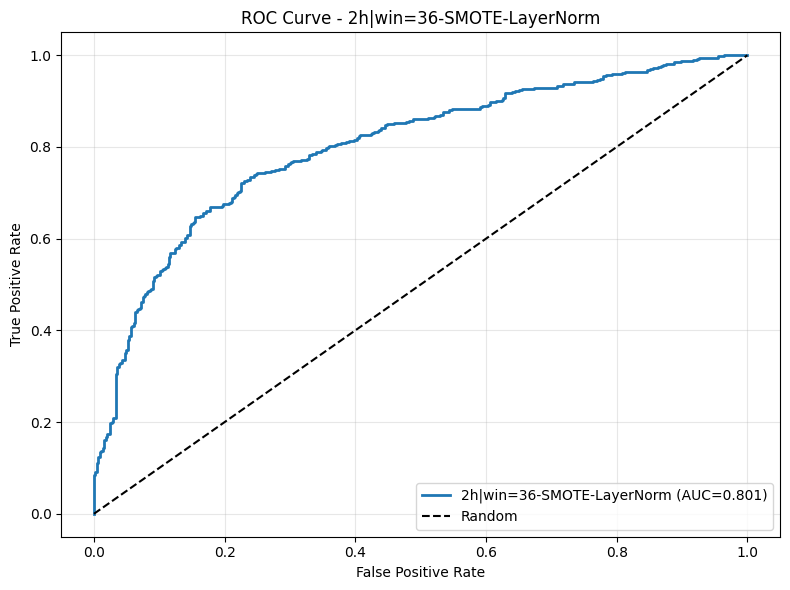

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_2h_win36-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_2h_win36-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\2h_win36-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 2661 samples, 21 batches/epoch, batch_size=128
Validation: 887 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6556 | Val Loss: 0.6352 | Val Acc: 0.5784 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5894 | Val Loss: 0.5784 | Val Acc: 0.6449 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5572 | Val Loss: 0.5702 | Val Acc: 0.6888 [UNDERFIT

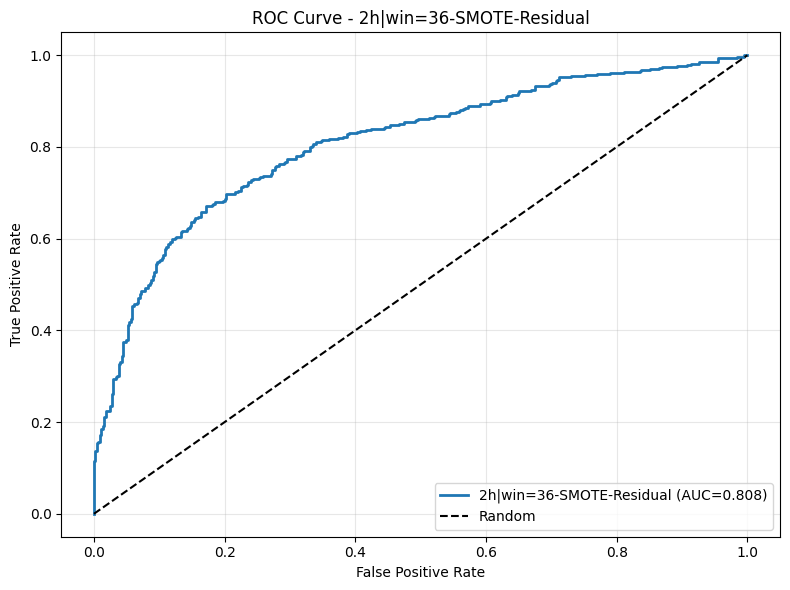

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_2h_win36-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_2h_win36-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\2h_win36-SMOTE-Residual

  Window Size: 48
    Data: 3613 samples, Class 0: 1402, Class 1: 2211

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 2652 samples, 21 batches/epoch, batch_size=128
Validation: 885 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6750 | Val Loss: 0.6548 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6148 | Val Loss: 0.5716 | Val Acc: 0.6475 [UNDERFITTING]
Epoch    3/500 | Train Loss

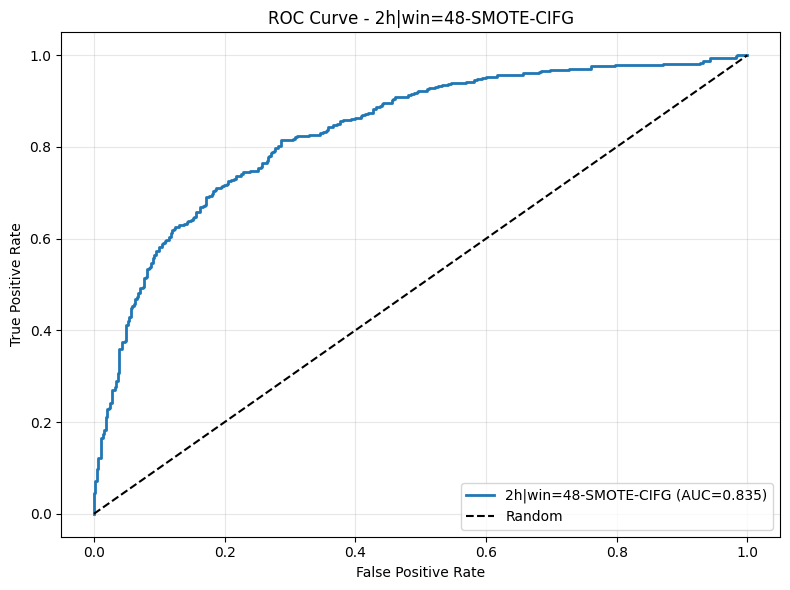

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_2h_win48-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_2h_win48-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\2h_win48-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 2652 samples, 21 batches/epoch, batch_size=128
Validation: 885 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6902 | Val Loss: 0.6848 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6780 | Val Loss: 0.6675 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.6230 | Val Loss: 0.5756 | Val Acc: 0.6441 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.570

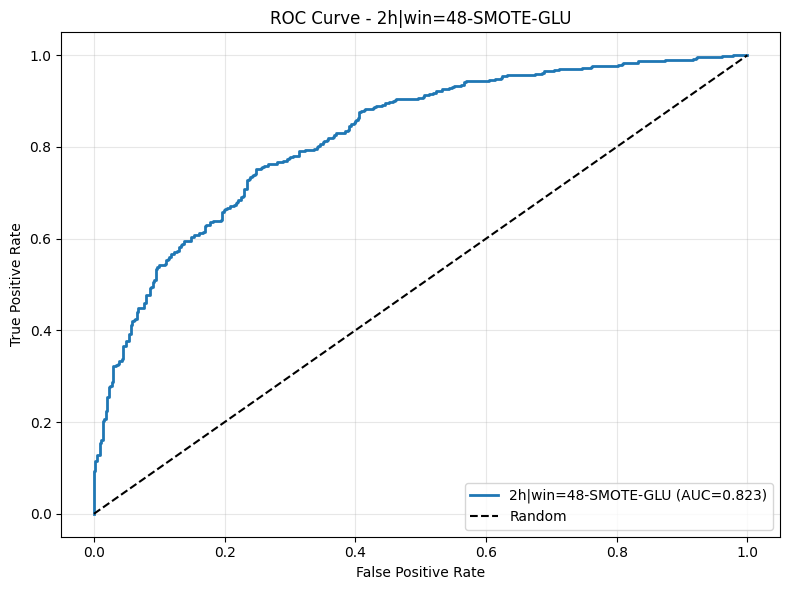

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_2h_win48-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_2h_win48-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\2h_win48-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 2652 samples, 21 batches/epoch, batch_size=128
Validation: 885 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6608 | Val Loss: 0.6109 | Val Acc: 0.6237 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6029 | Val Loss: 0.5868 | Val Acc: 0.6203 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5769 | Val Loss: 0.5455 | Val Acc: 0.6983 [UNDERFITTING]
Epoch    4/500 | Trai

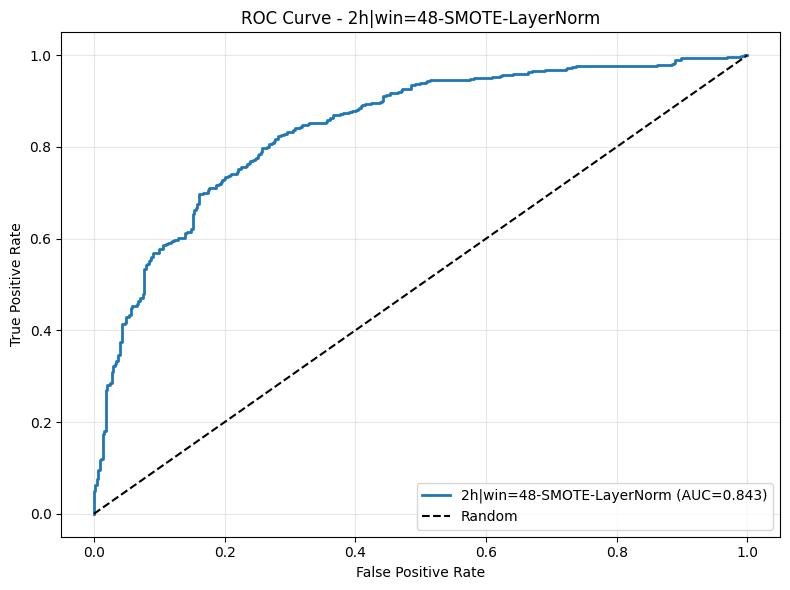

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_2h_win48-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_2h_win48-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\2h_win48-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 2652 samples, 21 batches/epoch, batch_size=128
Validation: 885 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6501 | Val Loss: 0.6095 | Val Acc: 0.5751 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5888 | Val Loss: 0.5543 | Val Acc: 0.6757 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5624 | Val Loss: 0.5436 | Val Acc: 0.6712 [UNDERFIT

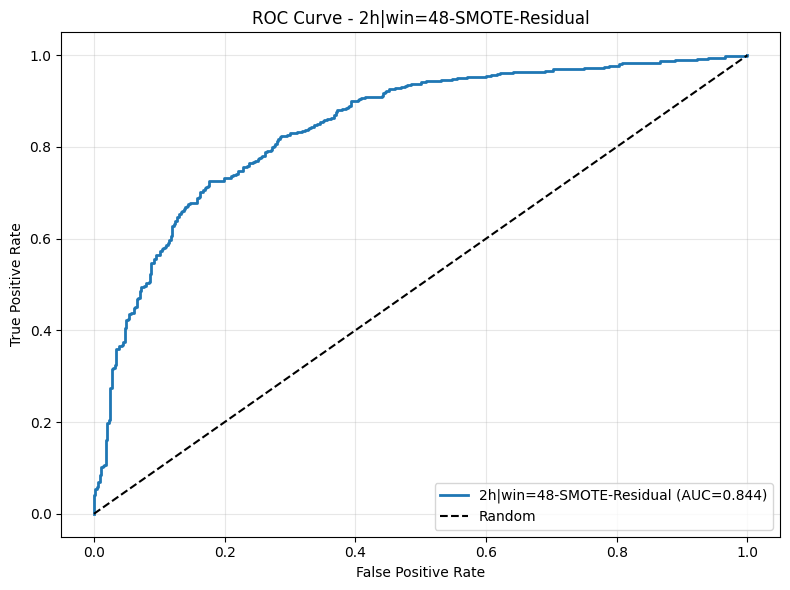

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_2h_win48-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_2h_win48-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\2h_win48-SMOTE-Residual

  Window Size: 60
    Data: 3601 samples, Class 0: 1398, Class 1: 2203

    🧠 Model Type: CIFG
      → Running SMOTE with CIFG...
💾 Datasets exported to ../data/splits/
🔧 Initializing CIFG LSTM model...
Training: 2643 samples, 21 batches/epoch, batch_size=128
Validation: 881 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6805 | Val Loss: 0.6680 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6275 | Val Loss: 0.5599 | Val Acc: 0.7037 [UNDERFITTING]
Epoch    3/500 | Train Loss

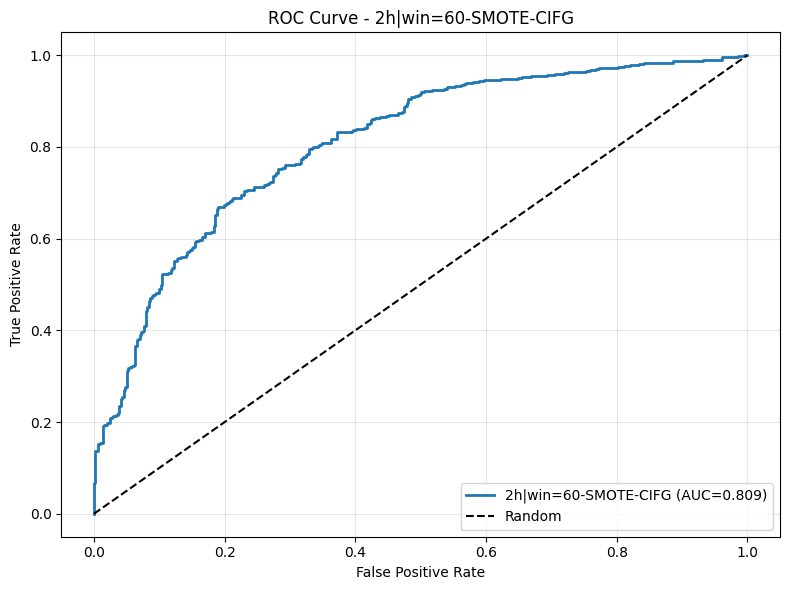

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_2h_win60-SMOTE-CIFG.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_cifg_2h_win60-SMOTE-CIFG.pkl
      ✅ Saved assets to: ../data/output\2h_win60-SMOTE-CIFG

    🧠 Model Type: GLU
      → Running SMOTE with GLU...
💾 Datasets exported to ../data/splits/
🔧 Initializing GLU LSTM model...
Training: 2643 samples, 21 batches/epoch, batch_size=128
Validation: 881 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6890 | Val Loss: 0.6831 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6770 | Val Loss: 0.6675 | Val Acc: 0.5006 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.6319 | Val Loss: 0.5795 | Val Acc: 0.6572 [UNDERFITTING]
Epoch    4/500 | Train Loss: 0.578

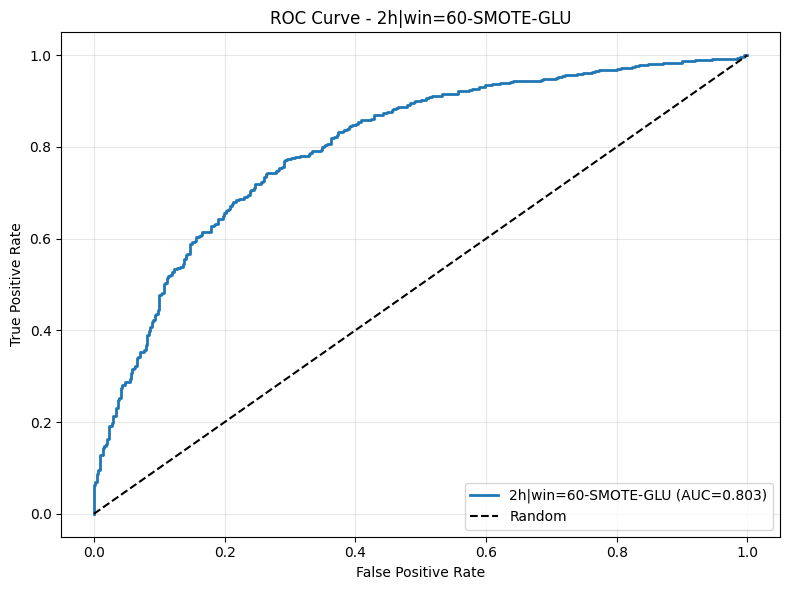

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_2h_win60-SMOTE-GLU.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_glu_2h_win60-SMOTE-GLU.pkl
      ✅ Saved assets to: ../data/output\2h_win60-SMOTE-GLU

    🧠 Model Type: LayerNorm
      → Running SMOTE with LayerNorm...
💾 Datasets exported to ../data/splits/
🔧 Initializing LayerNorm LSTM model...
Training: 2643 samples, 21 batches/epoch, batch_size=128
Validation: 881 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6767 | Val Loss: 0.6739 | Val Acc: 0.4994 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.6246 | Val Loss: 0.5685 | Val Acc: 0.6118 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5621 | Val Loss: 0.5581 | Val Acc: 0.6890 [UNDERFITTING]
Epoch    4/500 | Trai

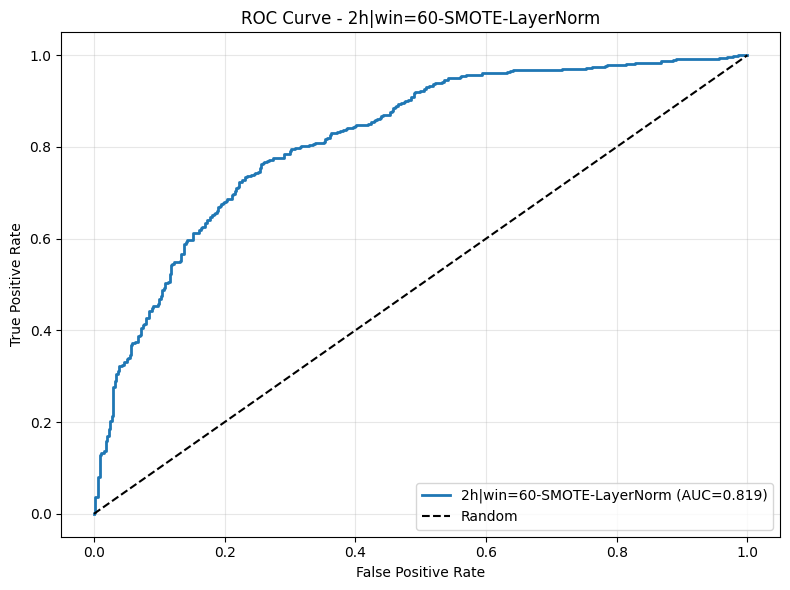

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_2h_win60-SMOTE-LayerNorm.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_layernorm_2h_win60-SMOTE-LayerNorm.pkl
      ✅ Saved assets to: ../data/output\2h_win60-SMOTE-LayerNorm

    🧠 Model Type: Residual
      → Running SMOTE with Residual...
💾 Datasets exported to ../data/splits/
🔧 Initializing Residual LSTM model...
Training: 2643 samples, 21 batches/epoch, batch_size=128
Validation: 881 samples | Early stopping patience: 3
----------------------------------------------------------------------
Epoch    1/500 | Train Loss: 0.6536 | Val Loss: 0.6207 | Val Acc: 0.5743 [UNDERFITTING]
Epoch    2/500 | Train Loss: 0.5952 | Val Loss: 0.5610 | Val Acc: 0.6436 [UNDERFITTING]
Epoch    3/500 | Train Loss: 0.5776 | Val Loss: 0.5568 | Val Acc: 0.6913 [UNDERFIT

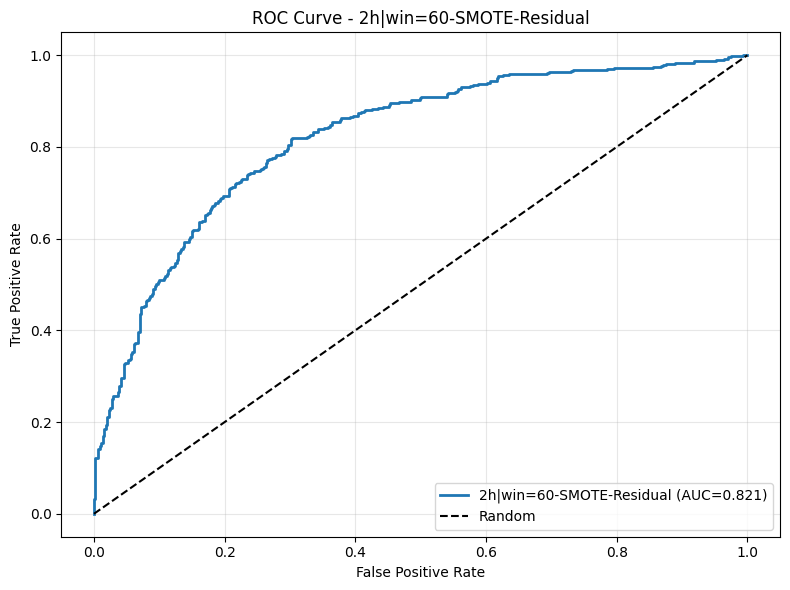

✅ Model saved to c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_2h_win60-SMOTE-Residual.pkl
💾 Model checkpoint saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\src/model/checkpoints\lstm_residual_2h_win60-SMOTE-Residual.pkl
      ✅ Saved assets to: ../data/output\2h_win60-SMOTE-Residual

✅ Experiment completed! Total results: 58
   Models tested: ['CIFG', 'GLU', 'LayerNorm', 'Residual']
   Results per model type: 14


In [21]:
# === 5. Run Experiment ==
sampling_periods = ['30min', '1h', '2h']
window_sizes = [12, 24, 36, 48, 60]
model_types = list(MODEL_REGISTRY.keys())  # ['Optimized', 'BiDirectional', 'Nested', 'Peephole']
results_all = []

for sp in sampling_periods:
    print(f"\n{'='*60}")
    print(f"Sampling Period: {sp}")
    print('='*60)
    
    df_resampled = (df.set_index('Timestamp')
                      .resample(sp)
                      .agg({'incident': 'sum', 'Priority': 'mean', 'Impact': 'mean'})
                      .fillna(0)
                      .reset_index())
    df_resampled['incident'] = (df_resampled['incident'] > 0).astype(int)

    for win in window_sizes:
        print(f"\n  Window Size: {win}")
        X, y, ts = create_windowed_dataset(df_resampled, ['Priority', 'Impact'], 'incident', win)
        
        if len(X) < 200 or len(np.unique(y)) < 2:
            print(f"    ⚠️ Skipped: Insufficient data (samples={len(X)}, classes={len(np.unique(y))})")
            continue

        X_flat = X.reshape((X.shape[0], -1))
        df_xy = pd.DataFrame(X_flat).assign(label=y)
        maj, min_class = df_xy[df_xy.label==0], df_xy[df_xy.label==1]
        
        if len(min_class) < 50:
            print(f"    ⚠️ Skipped: Too few minority samples ({len(min_class)})")
            continue

        print(f"    Data: {len(X)} samples, Class 0: {len(maj)}, Class 1: {len(min_class)}")

        # === Loop through all model types ===
        for model_type in model_types:
            print(f"\n    {'='*50}")
            print(f"    🧠 Model Type: {model_type}")
            print(f"    {'='*50}")

            # # 1. Undersampling
            # if len(maj) >= len(min_class):
            #     maj_down = resample(maj, replace=False, n_samples=len(min_class), random_state=42)
            #     under = pd.concat([maj_down, min_class])
            #     Xu = under.drop('label', axis=1).values.reshape((-1, win, 2))
            #     yu = under.label.values
                
            #     print(f"      → Running Undersampling with {model_type}...")
            #     result = train_eval(Xu, yu, label=f"{sp}|win={win}-Undersampled-{model_type}", model_type=model_type)
            #     results_all.append(result)
            #     save_model_assets(result)

            # 2. SMOTE
            try:
                print(f"      → Running SMOTE with {model_type}...")
                X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_flat, y)
                Xs = X_sm.reshape((-1, win, 2))
                result = train_eval(Xs, y_sm, label=f"{sp}|win={win}-SMOTE-{model_type}", model_type=model_type)
                results_all.append(result)
                save_model_assets(result) 
            except Exception as e:
                print(f"      ✗ SMOTE failed for {model_type}: {e}")
                continue

            # 3. Class Weight (weighted loss on original imbalanced data)
            # cw_vals = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
            # cw_ratio = cw_vals[1] / cw_vals[0]  # Relative weight for class 1
            # print(f"      → Running Class Weight ({cw_ratio:.2f}x) with {model_type}...")
            # result = train_eval(X, y, label=f"{sp}|win={win}-ClassWeight-{model_type}", model_type=model_type, cw=cw_ratio)
            # results_all.append(result)
            # save_model_assets(result)


print(f"\n{'='*60}")
print(f"✅ Experiment completed! Total results: {len(results_all)}")
print(f"   Models tested: {model_types}")
print(f"   Results per model type: {len(results_all) // len(model_types) if results_all else 0}")
print('='*60)


📊 FINAL COMPARATIVE METRICS TABLE (Sorted by F1-Score)


,Model,ModelType,Accuracy,Precision,Recall,F1_Score,AUC,TrainingTime
0,30min|win=60-SMOTE-CIFG,CIFG,0.8111,0.8262,0.7881,0.8067,0.8958,2097.4803
1,30min|win=48-SMOTE-CIFG,CIFG,0.8079,0.8227,0.7849,0.8033,0.8953,1633.5664
2,30min|win=36-SMOTE-CIFG,CIFG,0.8093,0.8330,0.7737,0.8023,0.8878,1418.9161
3,30min|win=36-SMOTE-Residual,Residual,0.8022,0.8068,0.7945,0.8006,0.8804,637.0420
4,30min|win=48-SMOTE-Residual,Residual,0.8121,0.8569,0.7493,0.7995,0.8948,921.8162
5,30min|win=48-SMOTE-GLU,GLU,0.8032,0.8209,0.7755,0.7976,0.8886,1896.2930
6,30min|win=60-SMOTE-Residual,Residual,0.8022,0.8235,0.7693,0.7955,0.8874,880.8817
7,30min|win=36-SMOTE-GLU,GLU,0.8024,0.8308,0.7594,0.7935,0.8799,2096.0461
8,30min|win=60-SMOTE-GLU,GLU,0.8022,0.8455,0.7396,0.7890,0.8880,2879.8621
9,30min|win=60-SMOTE-LayerNorm,LayerNorm,0.7856,0.7834,0.7896,0.7865,0.8725,3652.0113



📈 SUMMARY BY MODEL TYPE (Mean Metrics)


,Accuracy,Precision,Recall,F1_Score,AUC,TrainingTime
ModelType,,,,,,
CIFG,0.7501,0.7546,0.7430,0.7485,0.8219,486.5790
GLU,0.7430,0.7538,0.7239,0.7382,0.8114,642.1125
LayerNorm,0.7432,0.7472,0.7359,0.7410,0.8123,736.4313
Residual,0.7539,0.7606,0.7430,0.7512,0.8265,332.6055



🎯 DETAILED ANALYSIS: 30min|win=60-SMOTE-CIFG
   Model Type: CIFG


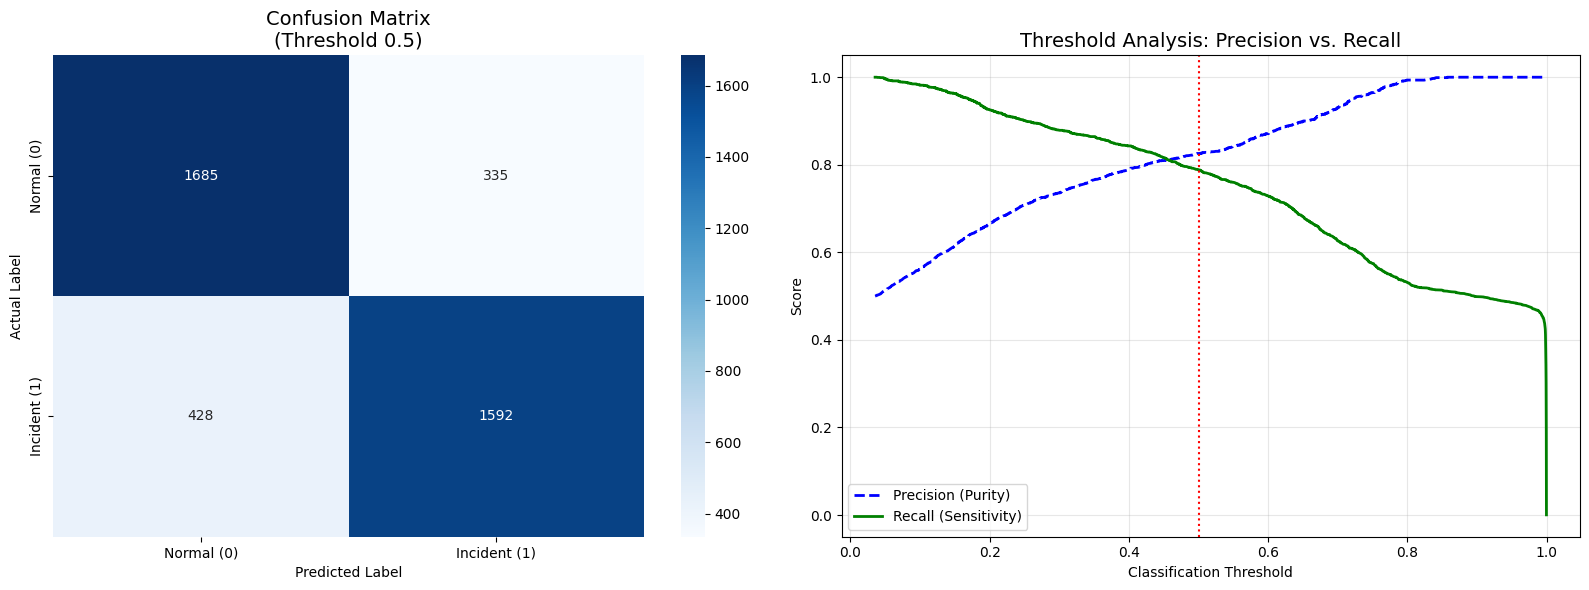

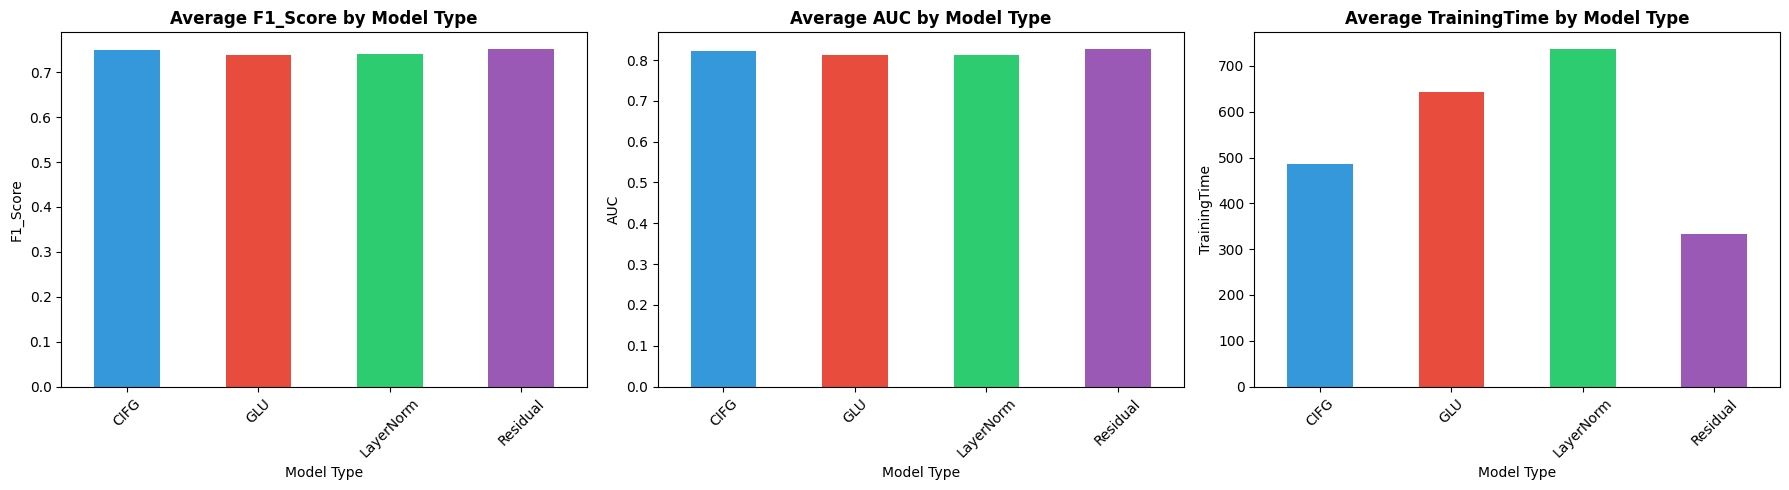


💡 RESOURCE OPTIMIZATION TIP:
   Untuk meminimalkan tebakan salah (High Precision), gunakan threshold: 0.424
   Pada titik ini, Precision akan berada di atas 80% dengan Recall sekitar 83.0%.


In [22]:
# === 6. Final Results Visualization & Comparison ===

# 1. Convert the results list to a Pandas DataFrame
res_df = pd.DataFrame(results_all)

# 2. Metadata Extraction
res_df[['Sampling','Window']] = res_df['Model'].str.extract(r'(\d+h|\d+min)\|win=(\d+)')
res_df['Window'] = res_df['Window'].fillna(0).astype(int)
res_df['Sampling'] = res_df['Sampling'].fillna('Unknown')

# Identify Method and Type
res_df['Method'] = res_df['Model'].apply(lambda m: 'SMOTE' if 'SMOTE' in m else ('Undersampled' if 'Under' in m else ('ClassWeight' if 'ClassWeight' in m else 'Original')))

# Sort by F1_Score or AUC to find the best model for detailed analysis
res_df = res_df.sort_values(by='F1_Score', ascending=False).reset_index(drop=True)

# --- A. Comparative Summary Table ---
print("\n" + "="*90)
print("📊 FINAL COMPARATIVE METRICS TABLE (Sorted by F1-Score)")
print("="*90)
display(res_df[['Model', 'ModelType', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC', 'TrainingTime']].round(4))

# --- A.1 Summary by Model Type ---
print("\n" + "="*90)
print("📈 SUMMARY BY MODEL TYPE (Mean Metrics)")
print("="*90)
model_summary = res_df.groupby('ModelType')[['Accuracy', 'Precision', 'Recall', 'F1_Score', 'AUC', 'TrainingTime']].mean()
display(model_summary.round(4))

# --- B. Detailed Analysis for the BEST MODEL ---
# Ambil data dari model peringkat pertama (Best Model)
best_model_data = res_df.iloc[0]
y_true = best_model_data['y_test']
y_pred = best_model_data['y_pred']
y_prob = best_model_data['y_prob']
model_label = best_model_data['Model']
model_type = best_model_data['ModelType']

print("\n" + "="*90)
print(f"🎯 DETAILED ANALYSIS: {model_label}")
print(f"   Model Type: {model_type}")
print("="*90)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Incident (1)'],
            yticklabels=['Normal (0)', 'Incident (1)'], ax=ax[0])
ax[0].set_title(f"Confusion Matrix\n(Threshold 0.5)", fontsize=14)
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

# 2. Threshold Analysis (Precision vs. Recall Trade-off)
precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)

ax[1].plot(thresholds, precisions[:-1], "b--", label="Precision (Purity)", linewidth=2)
ax[1].plot(thresholds, recalls[:-1], "g-", label="Recall (Sensitivity)", linewidth=2)
ax[1].set_xlabel("Classification Threshold")
ax[1].set_ylabel("Score")
ax[1].set_title("Threshold Analysis: Precision vs. Recall", fontsize=14)
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

# Tambahkan garis bantu untuk melihat dampak terhadap False Positive (Precision)
# Sesuai kebutuhan Anda: meminimalkan False Positive = Mengejar Precision Tinggi
ax[1].axvline(x=0.5, color='red', linestyle=':', label='Default Threshold (0.5)')
plt.tight_layout()
plt.show()

# --- C. Model Type Performance Comparison Bar Chart ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['F1_Score', 'AUC', 'TrainingTime']

for idx, metric in enumerate(metrics_to_plot):
    model_summary[metric].plot(kind='bar', ax=axes[idx], color=['#3498db', '#e74c3c', '#2ecc71', '#9b59b6'])
    axes[idx].set_title(f'Average {metric} by Model Type', fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].set_xlabel('Model Type')
    axes[idx].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

# --- D. Threshold Optimization for Resource Efficiency ---
# Mencari threshold terbaik jika ingin Precision > 0.8 (Hemat Resource)
target_precision = 0.80
idx = np.where(precisions >= target_precision)[0]

if len(idx) > 0:
    opt_threshold = thresholds[idx[0]]
    opt_recall = recalls[idx[0]]
    print(f"\n💡 RESOURCE OPTIMIZATION TIP:")
    print(f"   Untuk meminimalkan tebakan salah (High Precision), gunakan threshold: {opt_threshold:.3f}")
    print(f"   Pada titik ini, Precision akan berada di atas {target_precision*100:.0f}% dengan Recall sekitar {opt_recall*100:.1f}%.")
else:
    print("\n[Notice]: Tidak ditemukan threshold yang mencapai target Precision tersebut.")